In [1]:
# =========================================================
# IMPORTS
# =========================================================


from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from nilearn import plotting


# Multivariate MEG Classification

## Overview

This analysis performs time-resolved multivariate classification on epoched MEG data to investigate whether the neural activity patterns associated with four experimental conditions can be distinguished from one another.

The analysis uses the spatial pattern of MEG activity across sensors at each time point as input to a machine-learning classifier. The classifier is trained to distinguish between the experimental conditions and is evaluated using cross-validation.

The main objective is to determine **when during the trial the MEG signal contains information that distinguishes the different experimental conditions**.

The four conditions included in the analysis are:

- **Stay Left**
- **Stay Right**
- **Shift Left**
- **Shift Right**

Classification is performed across time, allowing the temporal evolution of condition-specific information in the MEG signal to be examined.


## Experimental Conditions

Four experimental conditions are used for classification. Each condition is identified by a specific event code in the epoched MEG data.

| Condition | Event code |
|---|---:|
| Stay Left | 9 |
| Stay Right | 13 |
| Shift Left | 17 |
| Shift Right | 21 |

The event codes are used to identify the trials belonging to each experimental condition.

The classification problem therefore consists of distinguishing between these four conditions based on their associated MEG activity.

---

## Temporal Averaging

No temporal averaging is currently applied:

```python
TEMPORAL_WINDOW_MS = None
WINDOW_STEP_MS = None
```

This means that the classifier operates on the MEG activity at each individual time point rather than averaging activity across a temporal window.

This preserves the temporal resolution of the MEG signal.

The analysis can alternatively be configured to use temporal windows. For example:

```python
TEMPORAL_WINDOW_MS = 50
WINDOW_STEP_MS = 25
```

would use 50-ms windows with a 25-ms step between consecutive windows.

---

## Training-Trial Averaging

Individual training trials are currently used without averaging:

```python
TRIAL_AVERAGING = 1
```

Therefore, each individual trial contributes separately to classifier training.

The analysis can alternatively average consecutive trials before training. For example:

```python
TRIAL_AVERAGING = 4
```

would average every four consecutive training trials.

The current analysis does not apply this averaging.

---

## Cross-Validation

Classifier performance is evaluated using **10-fold cross-validation**:

```python
N_SPLITS = 10
```

Cross-validation is used to evaluate whether the classifier can generalize to trials that were not used during training.

The trials are divided into 10 folds. For each iteration:

1. Nine folds are used to train the classifier.
2. One fold is held out as the test set.
3. The trained classifier is used to predict the conditions of the held-out trials.
4. Classification performance is calculated.
5. The procedure is repeated until each fold has been used as the test set.

This provides an estimate of classification performance on unseen trials rather than evaluating the classifier on the same trials used for training.

---

## Classifier

The classification model is **logistic regression**.

The classifier uses the `liblinear` solver:

```python
CLASSIFIER_SOLVER = "liblinear"
CLASSIFIER_MAX_ITER = 5000
```

The maximum number of iterations is set to 5000 to allow sufficient iterations for the optimization procedure to converge.

---

## Regularization

The logistic regression classifier uses **L1 regularization**:

```python
REGULARIZATION = "l1"
```

L1 regularization encourages a sparse classifier solution by penalizing the magnitude of the model weights and allowing some weights to become zero.

This is useful for constraining the classifier when working with a large number of MEG features.

---

## Regularization Strength

The regularization strength is controlled by:

```python
REGULARIZATION_STRENGTH = 1.0
```

For logistic regression, this corresponds to the parameter `C`.

The relationship between `C` and regularization strength is:

- Smaller `C` → stronger regularization
- Larger `C` → weaker regularization

The current analysis therefore uses:

```text
C = 1.0
```

---

## Classifier Weights

Classifier weights are examined over the time interval from **0 to 0.1 seconds**:

```python
WEIGHT_START_SEC = 0.0
WEIGHT_END_SEC = 0.1
```

This corresponds to the period between:

```text
0–100 ms
```

The classifier weights describe the contribution of the MEG features to the decision boundary learned by the logistic regression model.

These weights can be used for subsequent visualization or analysis of the spatial features contributing to classification.

Classifier weights should not be interpreted directly as measures of neural activation. They represent the features used by the classifier and can be affected by correlations between MEG sensors.

---

## Main Analysis Parameters

The current analysis uses the following settings:

| Parameter | Value |
|---|---:|
| Sampling frequency | 100 Hz |
| Temporal averaging | None |
| Temporal window | None |
| Window step | None |
| Training-trial averaging | 1 |
| Cross-validation | 10-fold |
| Classifier | Logistic regression |
| Solver | `liblinear` |
| Regularization | L1 |
| Regularization strength (`C`) | 1.0 |
| Maximum iterations | 5000 |
| Random seed | 42 |
| Weight analysis interval | 0–100 ms |

---

## Summary

This analysis uses time-resolved multivariate classification to investigate whether MEG activity contains information that distinguishes four experimental conditions:

- **Stay Left**
- **Stay Right**
- **Shift Left**
- **Shift Right**

The MEG data are resampled to 100 Hz and classification is performed independently at each time point without temporal or trial averaging.

A logistic regression classifier with L1 regularization is used, and performance is evaluated using 10-fold cross-validation.

The resulting classification time course can be used to identify **when condition-specific information is present in the MEG signal**, while the classifier weights can be examined to investigate the spatial features contributing to the classification.

In [ ]:
# %%
# =========================================================
# SETTINGS
# =========================================================

# ---------------------------------------------------------
# DATA PATH
# ---------------------------------------------------------

data_path = Path("/path/to/your/data") 


# ---------------------------------------------------------
# OUTPUT PATH
# ---------------------------------------------------------

output_path = Path("/path/to/your/directory") 

output_path.mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------
# FIND PARTICIPANT FILES
# ---------------------------------------------------------

files = sorted(
    data_path.glob("Sub*_epo.fif")
)


# ---------------------------------------------------------
# CONDITIONS
# ---------------------------------------------------------

conditions = {
    "stay_left": "9",
    "stay_right": "13",
    "shift_left": "17",
    "shift_right": "21"
}


# ---------------------------------------------------------
# RANDOMNESS
# ---------------------------------------------------------

RANDOM_SEED = 42


# ---------------------------------------------------------
# SAMPLING FREQUENCY
# ---------------------------------------------------------

RESAMPLE_FREQ = 100


# =========================================================
# TEMPORAL AVERAGING
# =========================================================

# None
#     No temporal averaging.
#     Classification at every original time point.
#
# Example:
#
# TEMPORAL_WINDOW_MS = 50
# WINDOW_STEP_MS = 25
#
# gives overlapping 50-ms windows.
#

TEMPORAL_WINDOW_MS = None


# Window step.
#
# Must also be None when TEMPORAL_WINDOW_MS is None.

WINDOW_STEP_MS = None


# =========================================================
# TRAINING TRIAL AVERAGING
# =========================================================

# 1
#     No trial averaging
#
# 2
#     Average every 2 training trials
#
# 4
#     Average every 4 training trials
#
# 6
#     Average every 6 training trials
#
# 8
#     Average every 8 training trials

TRIAL_AVERAGING = 1


# =========================================================
# CROSS-VALIDATION
# =========================================================

N_SPLITS = 10


# =========================================================
# CLASSIFIER
# =========================================================

CLASSIFIER_SOLVER = "liblinear"

CLASSIFIER_MAX_ITER = 5000


# ---------------------------------------------------------
# REGULARIZATION
# ---------------------------------------------------------

# "l1"
#     LASSO-like sparse logistic regression
#
# "l2"
#     Ridge-like logistic regression

REGULARIZATION = "l1"


# ---------------------------------------------------------
# REGULARIZATION STRENGTH
# ---------------------------------------------------------

# Smaller C
#     stronger regularization
#
# Larger C
#     weaker regularization

REGULARIZATION_STRENGTH = 1.0


# =========================================================
# CLASSIFIER WEIGHT TIME INTERVAL
# =========================================================

WEIGHT_START_SEC = 0.0

WEIGHT_END_SEC = 0.1
# %%
# =========================================================
# PRINT PARTICIPANTS
# =========================================================

print("\n==============================================")
print("PARTICIPANTS")
print("==============================================")

for f in files:

    print(
        f.name
    )

print(
    f"\nNumber of participants: {len(files)}"
)

print("==============================================\n")



PARTICIPANTS
Sub10_epo.fif
Sub11_epo.fif
Sub12_epo.fif
Sub13_epo.fif
Sub14_epo.fif
Sub15_epo.fif
Sub16_epo.fif
Sub17_epo.fif
Sub18_epo.fif
Sub1_epo.fif
Sub2_epo.fif
Sub3_epo.fif
Sub4_epo.fif
Sub5_epo.fif
Sub6_epo.fif
Sub7_epo.fif
Sub8_epo.fif
Sub9_epo.fif

Number of participants: 18



# Classification Functions and Decoding Pipeline

## Overview

This section defines the functions used to perform the multivariate MEG decoding analysis.

The decoding pipeline performs **one-vs-rest classification** for a selected target condition. The target condition is compared against all other conditions combined into a single "other" class.

The main steps of the decoding pipeline are:

1. Select trials belonging to the target condition.
2. Select trials belonging to all other conditions.
3. Balance the number of target and other trials.
4. Optionally average MEG activity within temporal windows.
5. Perform cross-validation separately at each time point or temporal window.
6. Within each cross-validation fold, average training trials if requested.
7. Standardize the MEG features using the training data only.
8. Train a regularized logistic regression classifier.
9. Test the classifier on individual held-out trials.
10. Calculate classification accuracy.
11. Extract and average the classifier weights across cross-validation folds.

The output consists of a time-resolved classification accuracy profile and time-resolved classifier weights.

---

## Trial Balancing

The `balance_trials()` function ensures that the target and comparison classes contain the same number of trials.

The function receives:

```python
X_target
X_other
rng

In [4]:
# =========================================================
# FUNCTION: BALANCE TRIALS
# =========================================================

def balance_trials(
    X_target,
    X_other,
    rng
):
    """
    Randomly select the same number of trials
    from target and other classes.
    """

    n = min(
        len(X_target),
        len(X_other)
    )

    idx_target = rng.choice(
        len(X_target),
        size=n,
        replace=False
    )

    idx_other = rng.choice(
        len(X_other),
        size=n,
        replace=False
    )

    return (
        X_target[idx_target],
        X_other[idx_other]
    )


# %%
# =========================================================
# FUNCTION: TEMPORAL AVERAGING
# =========================================================

def temporal_average(
    X,
    times,
    window_ms,
    step_ms
):
    """
    Average MEG data within temporal windows.

    Parameters
    ----------
    X : ndarray

        Shape:
            trials × channels × time

    times : ndarray

        Time vector in seconds.

    window_ms : float

        Temporal window duration in milliseconds.

    step_ms : float

        Distance between consecutive windows in milliseconds.


    Returns
    -------
    X_windowed : ndarray

        Shape:
            trials × channels × windows


    window_times : ndarray

        Center time of each temporal window.
    """

    # -----------------------------------------------------
    # NO TEMPORAL AVERAGING
    # -----------------------------------------------------

    if window_ms is None:

        return (
            X,
            times
        )


    # -----------------------------------------------------
    # PARAMETER CHECKS
    # -----------------------------------------------------

    if step_ms is None:

        raise ValueError(
            "WINDOW_STEP_MS cannot be None when "
            "TEMPORAL_WINDOW_MS is specified."
        )


    if window_ms <= 0:

        raise ValueError(
            "TEMPORAL_WINDOW_MS must be > 0."
        )


    if step_ms <= 0:

        raise ValueError(
            "WINDOW_STEP_MS must be > 0."
        )


    # -----------------------------------------------------
    # CONVERT MS TO SECONDS
    # -----------------------------------------------------

    window_sec = (
        window_ms / 1000.0
    )

    step_sec = (
        step_ms / 1000.0
    )


    # -----------------------------------------------------
    # TIME RANGE
    # -----------------------------------------------------

    start_time = times[0]

    end_time = times[-1]


    # -----------------------------------------------------
    # WINDOW START TIMES
    # -----------------------------------------------------

    starts = np.arange(
        start_time,
        end_time - window_sec + 1e-12,
        step_sec
    )


    # -----------------------------------------------------
    # STORAGE
    # -----------------------------------------------------

    windowed_data = []

    window_times = []


    # -----------------------------------------------------
    # LOOP WINDOWS
    # -----------------------------------------------------

    for start in starts:

        stop = (
            start +
            window_sec
        )


        mask = (
            (times >= start)
            &
            (times < stop)
        )


        # Skip empty windows

        if not np.any(mask):

            continue


        # Average time samples

        X_mean = np.mean(
            X[:, :, mask],
            axis=2
        )


        windowed_data.append(
            X_mean
        )


        # Window center

        center = (
            start +
            window_sec / 2
        )


        window_times.append(
            center
        )


    # -----------------------------------------------------
    # CONVERT TO ARRAYS
    # -----------------------------------------------------

    X_windowed = np.stack(
        windowed_data,
        axis=2
    )


    window_times = np.asarray(
        window_times
    )


    return (
        X_windowed,
        window_times
    )


# %%
# =========================================================
# FUNCTION: AVERAGE TRAINING TRIALS
# =========================================================

def average_trials(
    X,
    y,
    n_average,
    rng
):
    """
    Average training trials WITHIN EACH CLASS.

    This function is intended to be called
    only inside a CV training fold.

    Test trials must never be passed here.


    Parameters
    ----------
    X : ndarray

        Shape:
            trials × channels


    y : ndarray

        Class labels.


    n_average : int

        Number of trials to average.


    Returns
    -------
    X_avg
        Averaged training data.


    y_avg
        Corresponding labels.
    """

    # -----------------------------------------------------
    # NO TRIAL AVERAGING
    # -----------------------------------------------------

    if n_average == 1:

        return (
            X,
            y
        )


    averaged_X = []

    averaged_y = []


    # -----------------------------------------------------
    # PROCESS EACH CLASS SEPARATELY
    # -----------------------------------------------------

    for class_label in np.unique(y):

        class_idx = np.where(
            y == class_label
        )[0]


        # Randomize trial order

        class_idx = rng.permutation(
            class_idx
        )


        # Number of complete groups

        n_groups = (
            len(class_idx)
            //
            n_average
        )


        # -------------------------------------------------
        # AVERAGE COMPLETE GROUPS
        # -------------------------------------------------

        for g in range(
            n_groups
        ):

            idx = class_idx[
                g * n_average:
                (g + 1) * n_average
            ]


            X_group = np.mean(
                X[idx],
                axis=0
            )


            averaged_X.append(
                X_group
            )


            averaged_y.append(
                class_label
            )


    # -----------------------------------------------------
    # CONVERT TO ARRAYS
    # -----------------------------------------------------

    X_avg = np.asarray(
        averaged_X
    )


    y_avg = np.asarray(
        averaged_y
    )


    # -----------------------------------------------------
    # SAFETY CHECK
    # -----------------------------------------------------

    if len(X_avg) == 0:

        raise ValueError(
            "Trial averaging produced zero training samples. "
            "Reduce TRIAL_AVERAGING."
        )


    # -----------------------------------------------------
    # SHUFFLE AVERAGED EXAMPLES
    # -----------------------------------------------------

    shuffle_idx = rng.permutation(
        len(X_avg)
    )


    X_avg = X_avg[
        shuffle_idx
    ]


    y_avg = y_avg[
        shuffle_idx
    ]


    return (
        X_avg,
        y_avg
    )


# %%
# =========================================================
# FUNCTION: DECODE CONDITION
# =========================================================

def decode_condition(
    epochs,
    target_event,
    other_events,
    rng,
    temporal_window_ms,
    window_step_ms,
    trial_averaging
):
    """
    One-vs-rest decoding.

    Pipeline
    --------

    1. Select target and other trials.

    2. Balance classes.

    3. Apply temporal averaging, if requested.

    4. At each time point/window:

        - Split CV.

        - Average training trials only.

        - Scale training data.

        - Apply same scaling to test data.

        - Train logistic regression.

        - Test on individual trials.


    Returns
    -------

    scores_time

        Classification accuracy across time/windows.


    weights_time

        Classifier weights across time/windows.


    decoding_times

        Original time points or temporal-window centers.
    """

    # =====================================================
    # SELECT TARGET
    # =====================================================

    epochs_target = epochs[
        target_event
    ]


    # =====================================================
    # SELECT OTHER CONDITIONS
    # =====================================================

    epochs_other = epochs[
        other_events
    ]


    # =====================================================
    # GET DATA
    # =====================================================

    X_target = epochs_target.get_data()

    X_other = epochs_other.get_data()


    # =====================================================
    # BALANCE CLASSES
    # =====================================================

    X_target, X_other = balance_trials(
        X_target,
        X_other,
        rng
    )


    # =====================================================
    # COMBINE DATA
    # =====================================================

    X = np.vstack([
        X_target,
        X_other
    ])


    # =====================================================
    # CREATE LABELS
    # =====================================================

    y = np.array(
        [1] * len(X_target)
        +
        [0] * len(X_other)
    )


    # =====================================================
    # TEMPORAL AVERAGING
    # =====================================================

    X, decoding_times = temporal_average(
        X=X,
        times=epochs.times,
        window_ms=temporal_window_ms,
        step_ms=window_step_ms
    )


    # =====================================================
    # DIMENSIONS
    # =====================================================

    n_trials, n_channels, n_times = X.shape


    print(
        f"        Trials: {n_trials}"
    )

    print(
        f"        Channels: {n_channels}"
    )

    print(
        f"        Time points/windows: {n_times}"
    )


    # =====================================================
    # STORAGE
    # =====================================================

    scores_time = np.zeros(
        n_times
    )


    weights_time = np.zeros(
        (
            n_times,
            n_channels
        )
    )


    # =====================================================
    # CROSS-VALIDATION
    # =====================================================

    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_SEED
    )


    # =====================================================
    # CLASSIFIER
    # =====================================================

    clf = LogisticRegression(
        solver=CLASSIFIER_SOLVER,
        max_iter=CLASSIFIER_MAX_ITER,
        penalty=REGULARIZATION,
        C=REGULARIZATION_STRENGTH
    )


    # =====================================================
    # DECODE EACH TIME POINT / WINDOW
    # =====================================================

    for t in range(
        n_times
    ):

        # -------------------------------------------------
        # DATA AT THIS TIME POINT / WINDOW
        # -------------------------------------------------

        X_t = X[
            :,
            :,
            t
        ]


        fold_scores = []

        fold_weights = []


        # =================================================
        # CROSS-VALIDATION
        # =================================================

        for train_idx, test_idx in cv.split(
            X_t,
            y
        ):

            # =================================================
            # RAW TRAINING DATA
            # =================================================

            X_train_raw = X_t[
                train_idx
            ]


            y_train = y[
                train_idx
            ]


            # =================================================
            # RAW TEST DATA
            #
            # NEVER TRIAL AVERAGED
            # =================================================

            X_test_raw = X_t[
                test_idx
            ]


            y_test = y[
                test_idx
            ]


            # =================================================
            # TRAINING TRIAL AVERAGING
            #
            # ONLY TRAINING DATA
            # =================================================

            X_train_raw, y_train = average_trials(
                X=X_train_raw,
                y=y_train,
                n_average=trial_averaging,
                rng=rng
            )


            # =================================================
            # SCALE FEATURES
            #
            # FIT ON TRAINING DATA ONLY
            # =================================================

            scaler = StandardScaler()


            X_train = scaler.fit_transform(
                X_train_raw
            )


            X_test = scaler.transform(
                X_test_raw
            )


            # =================================================
            # FIT CLASSIFIER
            # =================================================

            clf.fit(
                X_train,
                y_train
            )


            # =================================================
            # PREDICT TEST DATA
            # =================================================

            y_pred = clf.predict(
                X_test
            )


            # =================================================
            # ACCURACY
            # =================================================

            fold_scores.append(
                accuracy_score(
                    y_test,
                    y_pred
                )
            )


            # =================================================
            # CLASSIFIER WEIGHTS
            # =================================================

            fold_weights.append(
                clf.coef_[0]
            )


        # =====================================================
        # AVERAGE CV RESULTS
        # =====================================================

        scores_time[t] = np.mean(
            fold_scores
        )


        weights_time[t] = np.mean(
            fold_weights,
            axis=0
        )


    return (
        scores_time,
        weights_time,
        decoding_times
    )



# Analysis Execution: MEG Decoding Across Participants

This section runs the complete time-resolved MEG decoding analysis for all participants and all experimental conditions.

The analysis proceeds in four main stages:

1. Initialize the random number generator.
2. Create a unique name describing the analysis configuration.
3. Load and resample each participant's MEG epochs.
4. Perform one-vs-rest decoding for each condition and store the resulting decoding scores and classifier weights.

The outputs are stored separately for each condition and participant, allowing group-level analysis and visualization after the decoding is complete.

---

## 1. Initialize Random Number Generator

```python
rng = np.random.default_rng(
    RANDOM_SEED
)

In [5]:
# =========================================================
# INITIALIZE RANDOM NUMBER GENERATOR
# =========================================================

rng = np.random.default_rng(
    RANDOM_SEED
)


# %%
# =========================================================
# CREATE ANALYSIS NAME
# =========================================================

if TEMPORAL_WINDOW_MS is None:

    temporal_name = (
        "no_temporal_avg"
    )

else:

    temporal_name = (
        f"window_{TEMPORAL_WINDOW_MS}ms_"
        f"step_{WINDOW_STEP_MS}ms"
    )


analysis_name = (
    f"logreg_"
    f"{REGULARIZATION}_"
    f"C{REGULARIZATION_STRENGTH}_"
    f"{RESAMPLE_FREQ}Hz_"
    f"{temporal_name}_"
    f"trialavg_{TRIAL_AVERAGING}"
)


# %%
# =========================================================
# PRINT SETTINGS
# =========================================================

print("\n==============================================")
print("MEG DECODING SETTINGS")
print("==============================================")

print(
    f"Sampling frequency: "
    f"{RESAMPLE_FREQ} Hz"
)

print(
    f"Temporal window: "
    f"{TEMPORAL_WINDOW_MS}"
)

print(
    f"Window step: "
    f"{WINDOW_STEP_MS}"
)

print(
    f"Training trial averaging: "
    f"{TRIAL_AVERAGING}"
)

print(
    f"CV folds: "
    f"{N_SPLITS}"
)

print(
    f"Regularization: "
    f"{REGULARIZATION}"
)

print(
    f"C: "
    f"{REGULARIZATION_STRENGTH}"
)

print(
    f"Analysis name: "
    f"{analysis_name}"
)

print("==============================================\n")


# %%
# =========================================================
# STORAGE
# =========================================================

all_scores = {
    cond: []
    for cond in conditions.keys()
}


all_weights = {
    cond: []
    for cond in conditions.keys()
}


times = None


# %%
# =========================================================
# LOAD DATA + RESAMPLE + DECODE
# =========================================================

for f in files:

    print(
        "\n=============================================="
    )

    print(
        f"Processing {f.name}"
    )

    print(
        "=============================================="
    )


    # =====================================================
    # LOAD EPOCHS
    # =====================================================

    epochs = mne.read_epochs(
        f,
        preload=True
    )


    # =====================================================
    # RESAMPLE
    # =====================================================

    print(
        f"    Resampling to "
        f"{RESAMPLE_FREQ} Hz..."
    )


    epochs.resample(
        RESAMPLE_FREQ
    )


    # =====================================================
    # DECODE EACH CONDITION
    # =====================================================

    for cond_name, target_event in conditions.items():

        print(
            f"\n    Decoding: {cond_name}"
        )


        # -------------------------------------------------
        # OTHER CONDITIONS
        # -------------------------------------------------

        other_events = [
            event
            for name, event in conditions.items()
            if event != target_event
        ]


        # -------------------------------------------------
        # DECODE
        # -------------------------------------------------

        scores, weights, decoding_times = (
            decode_condition(
                epochs=epochs,
                target_event=target_event,
                other_events=other_events,
                rng=rng,
                temporal_window_ms=TEMPORAL_WINDOW_MS,
                window_step_ms=WINDOW_STEP_MS,
                trial_averaging=TRIAL_AVERAGING
            )
        )


        # -------------------------------------------------
        # STORE SCORES
        # -------------------------------------------------

        all_scores[
            cond_name
        ].append(
            scores
        )


        # -------------------------------------------------
        # STORE WEIGHTS
        # -------------------------------------------------

        all_weights[
            cond_name
        ].append(
            weights
        )


        # -------------------------------------------------
        # SAVE TIME VECTOR
        # -------------------------------------------------

        if times is None:

            times = decoding_times


# %%
# =========================================================
# DECODING FINISHED
# =========================================================

print(
    "\n=============================================="
)

print(
    "DECODING FINISHED"
)

print(
    "=============================================="
)




MEG DECODING SETTINGS
Sampling frequency: 100 Hz
Temporal window: None
Window step: None
Training trial averaging: 1
CV folds: 10
Regularization: l1
C: 1.0
Analysis name: logreg_l1_C1.0_100Hz_no_temporal_avg_trialavg_1


Processing Sub10_epo.fif
Reading /home/uranus/Scrivania/MEG_replay/epoched_data/Sub10_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -499.51 ...    1000.98 ms
        0 CTF compensation matrices available
Not setting metadata
360 matching events found
No baseline correction applied
0 projection items activated
    Resampling to 100 Hz...

    Decoding: stay_left
        Trials: 180
        Channels: 99
        Time points/windows: 150

    Decoding: stay_right
        Trials: 186
        Channels: 99
        Time points/windows: 150

    Decoding: shift_left
        Trials: 176
        Channels: 99
        Time points/windows: 150

    Decoding: shift_right
        Trials: 178
        Channels: 99
        Time points/windows: 150

Process


Coordinates loaded.
Number of coordinates: 99

===== DEBUG =====
Times shape: (150,)
stay_left scores shape: (150,)
stay_left participants: 18
stay_right scores shape: (150,)
stay_right participants: 18
shift_left scores shape: (150,)
shift_left participants: 18
shift_right scores shape: (150,)
shift_right participants: 18



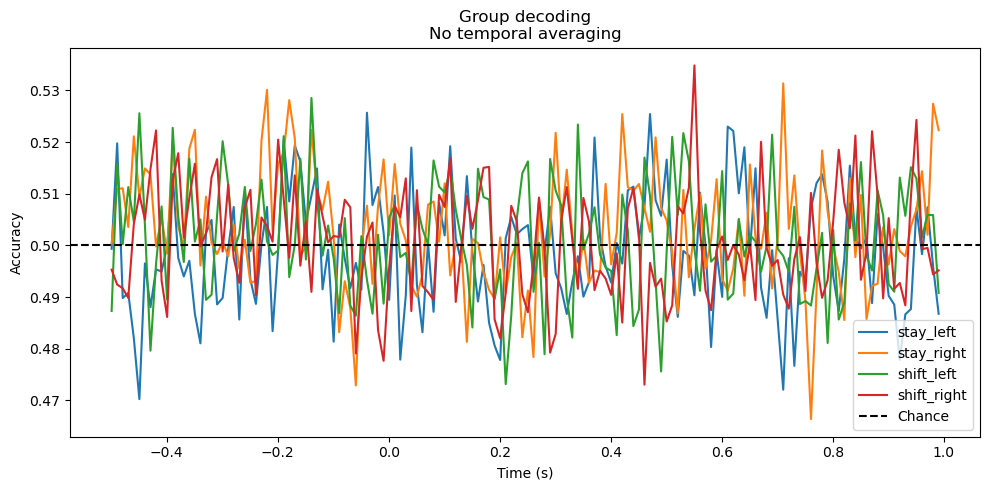

Saved plot: /home/uranus/Scrivania/MEG_replay/figures/logreg_l1_C1.0_100Hz_no_temporal_avg_trialavg_1_group_average.png


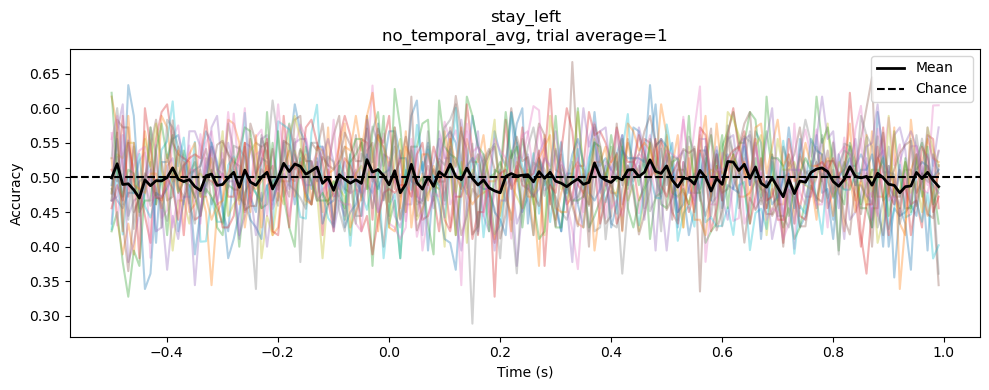

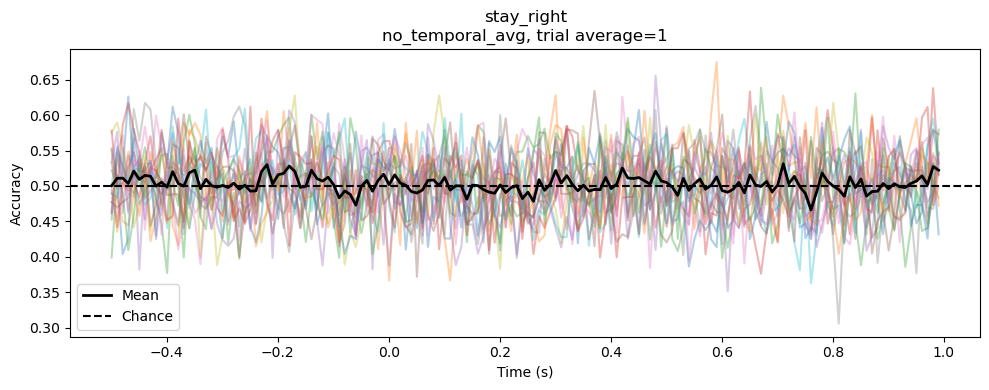

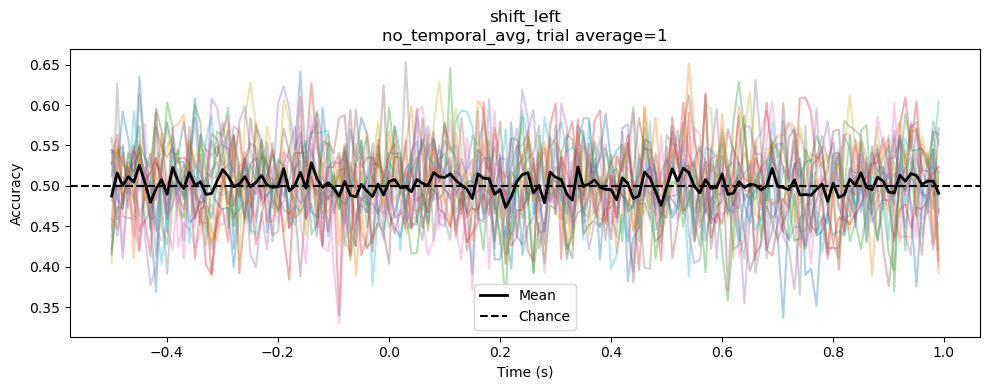

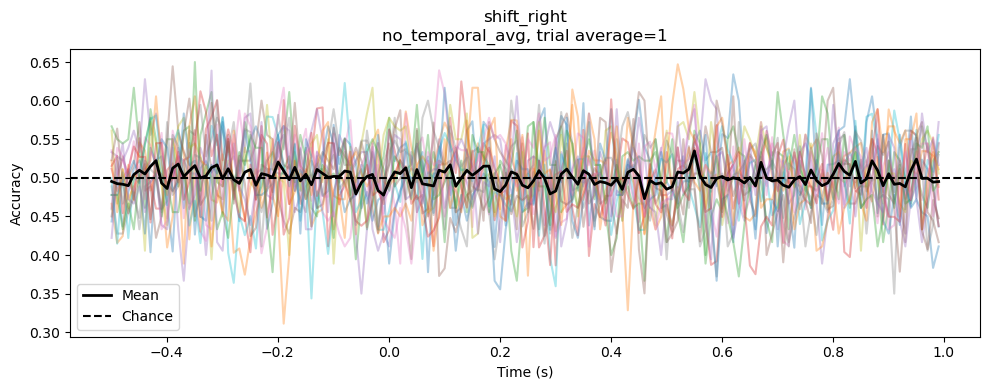

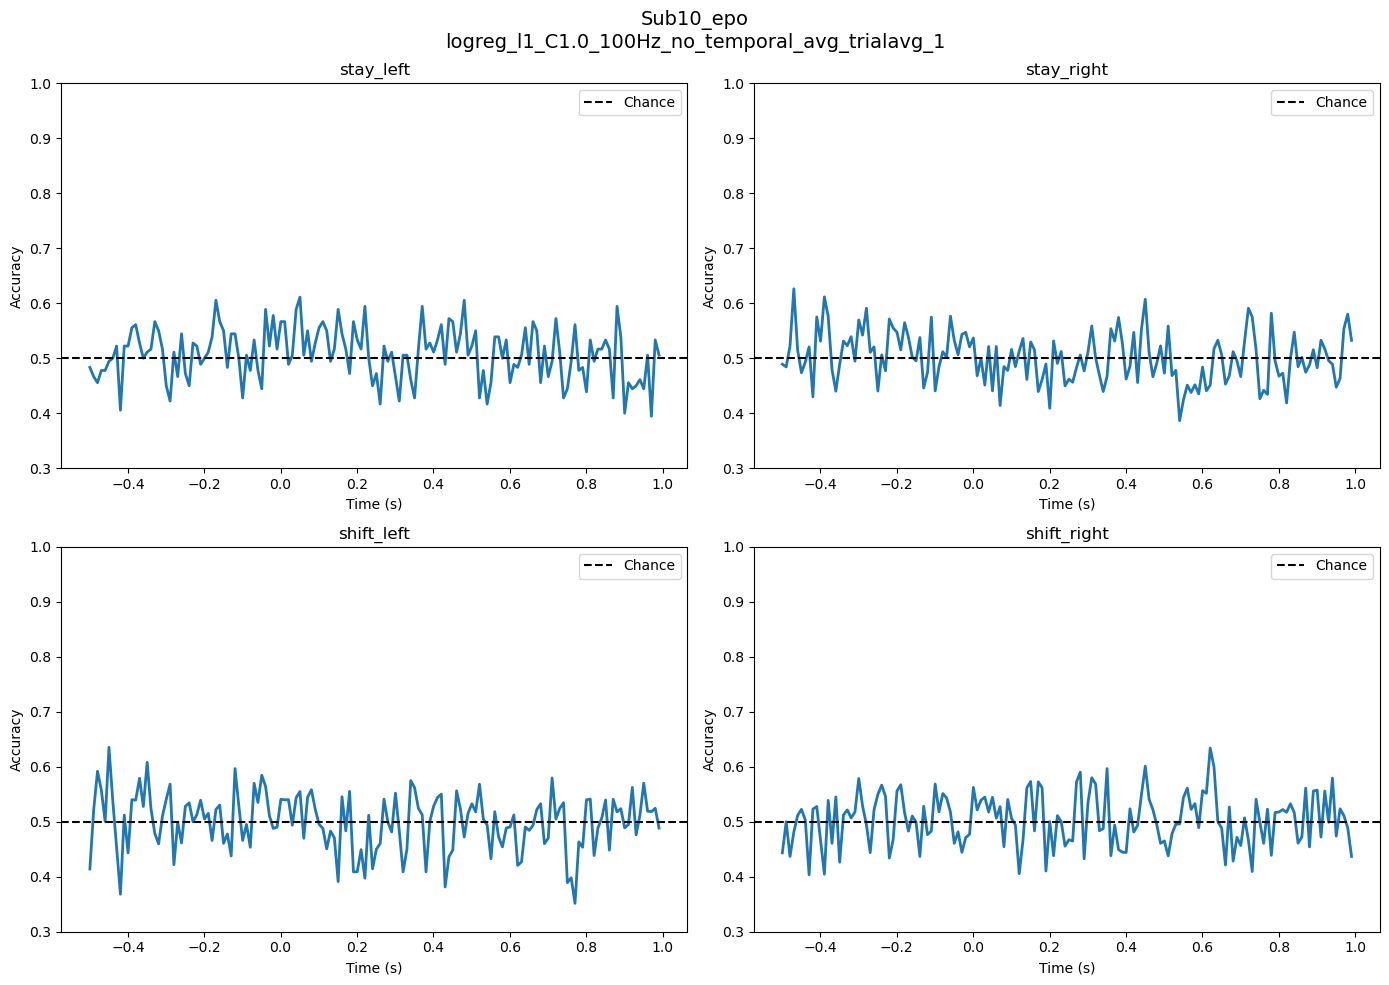

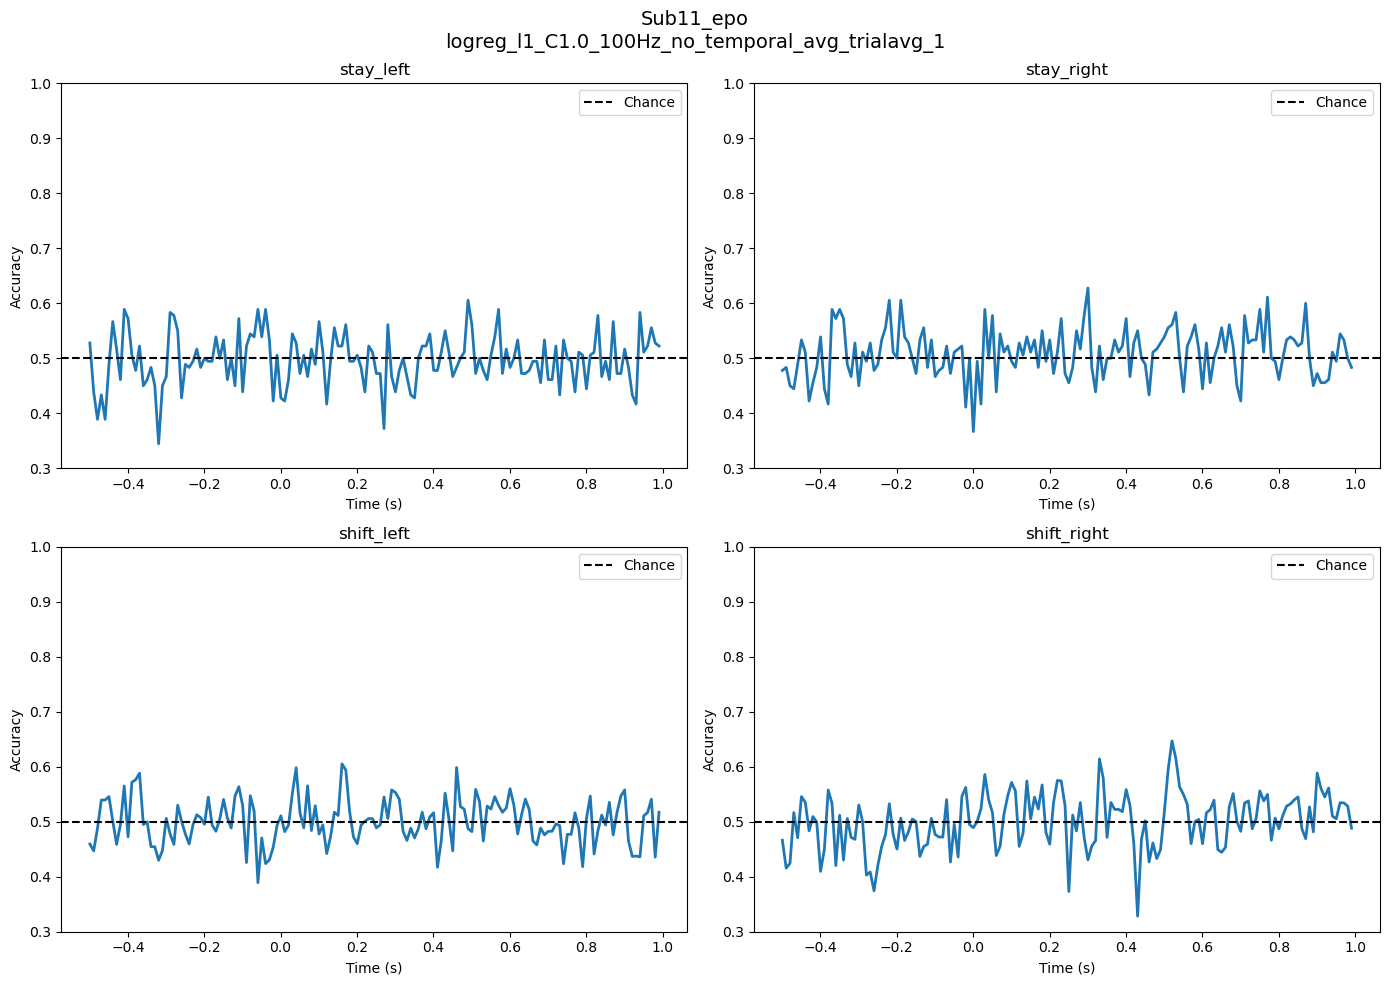

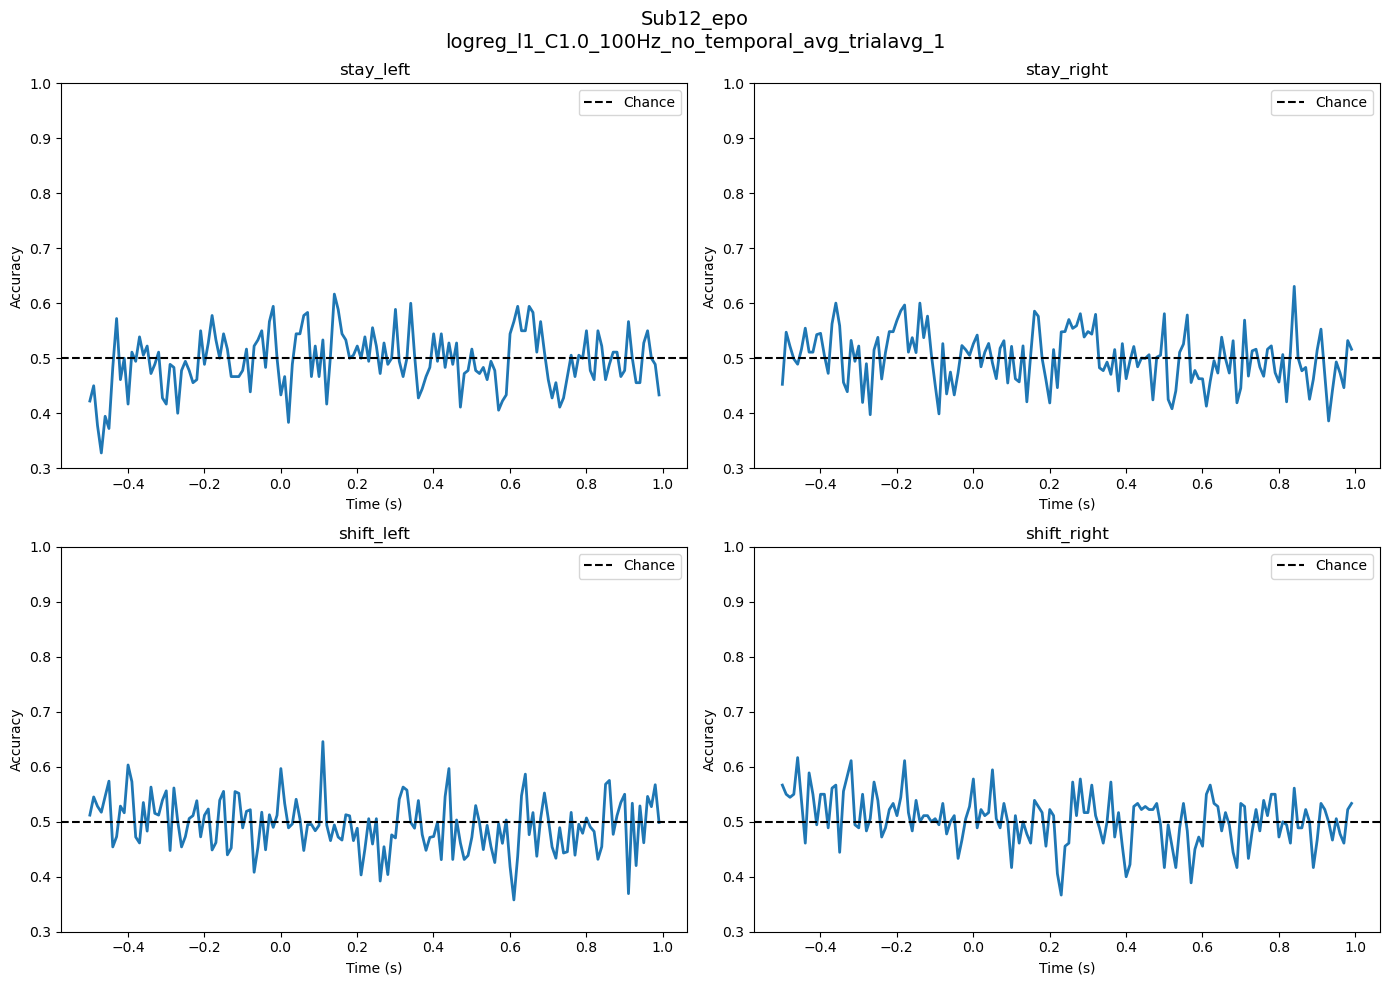

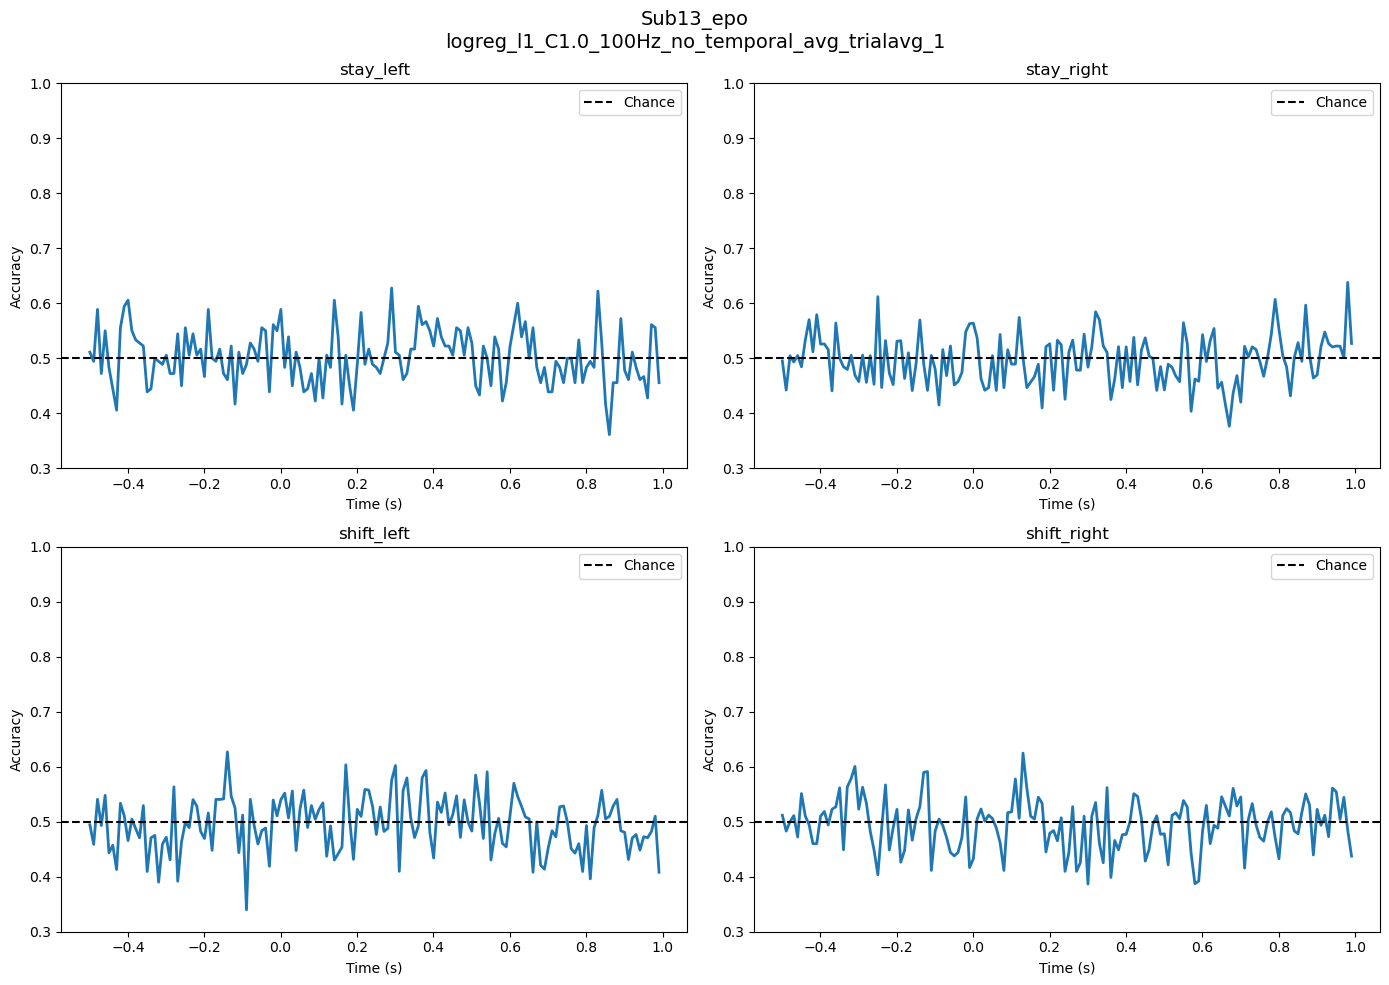

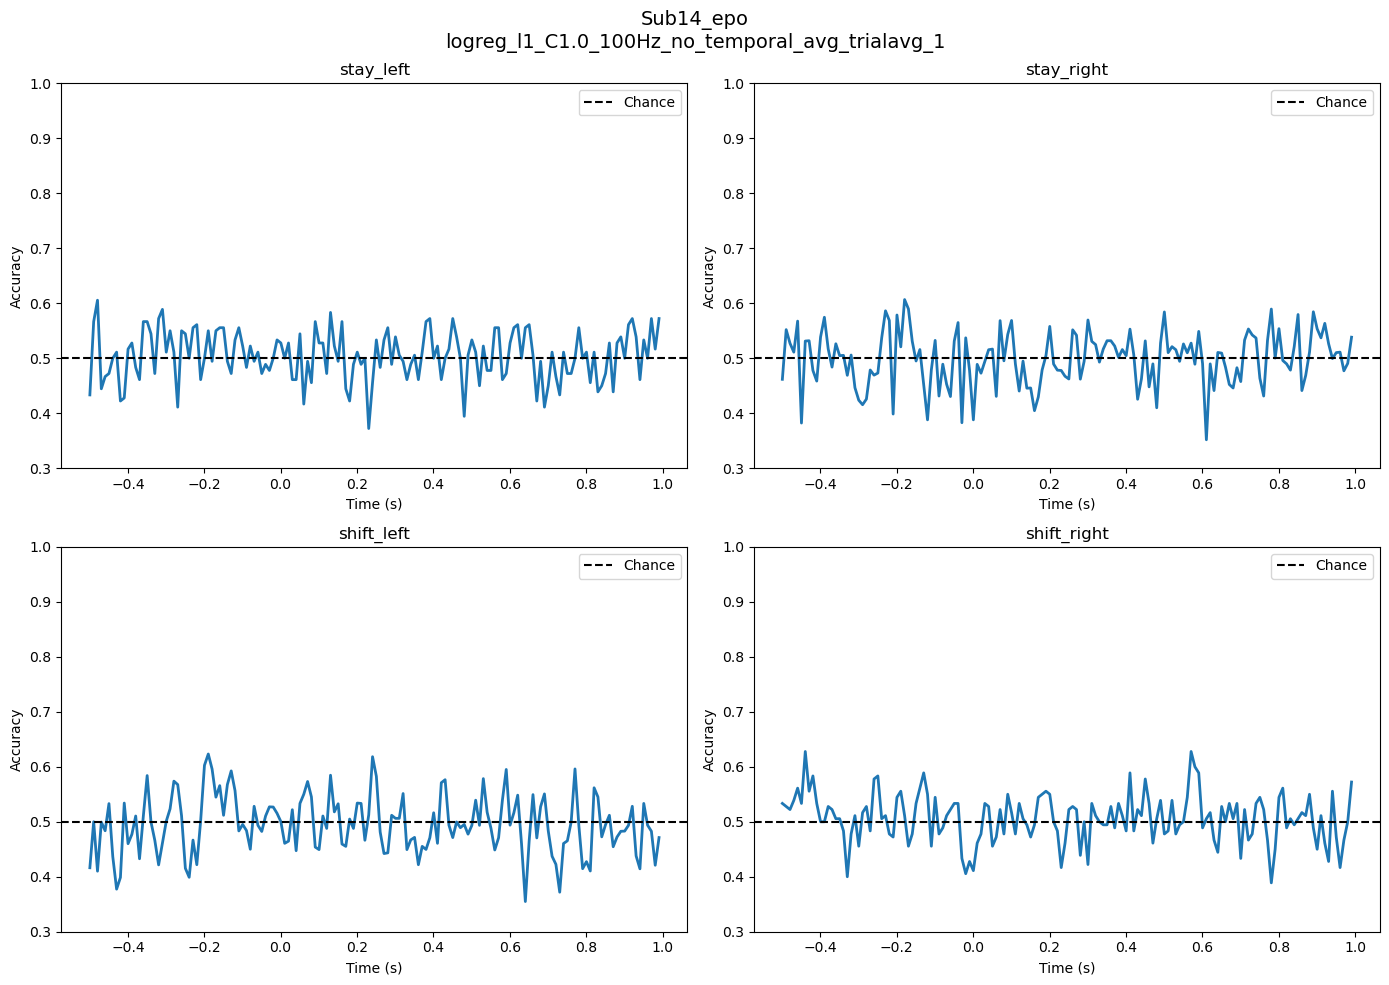

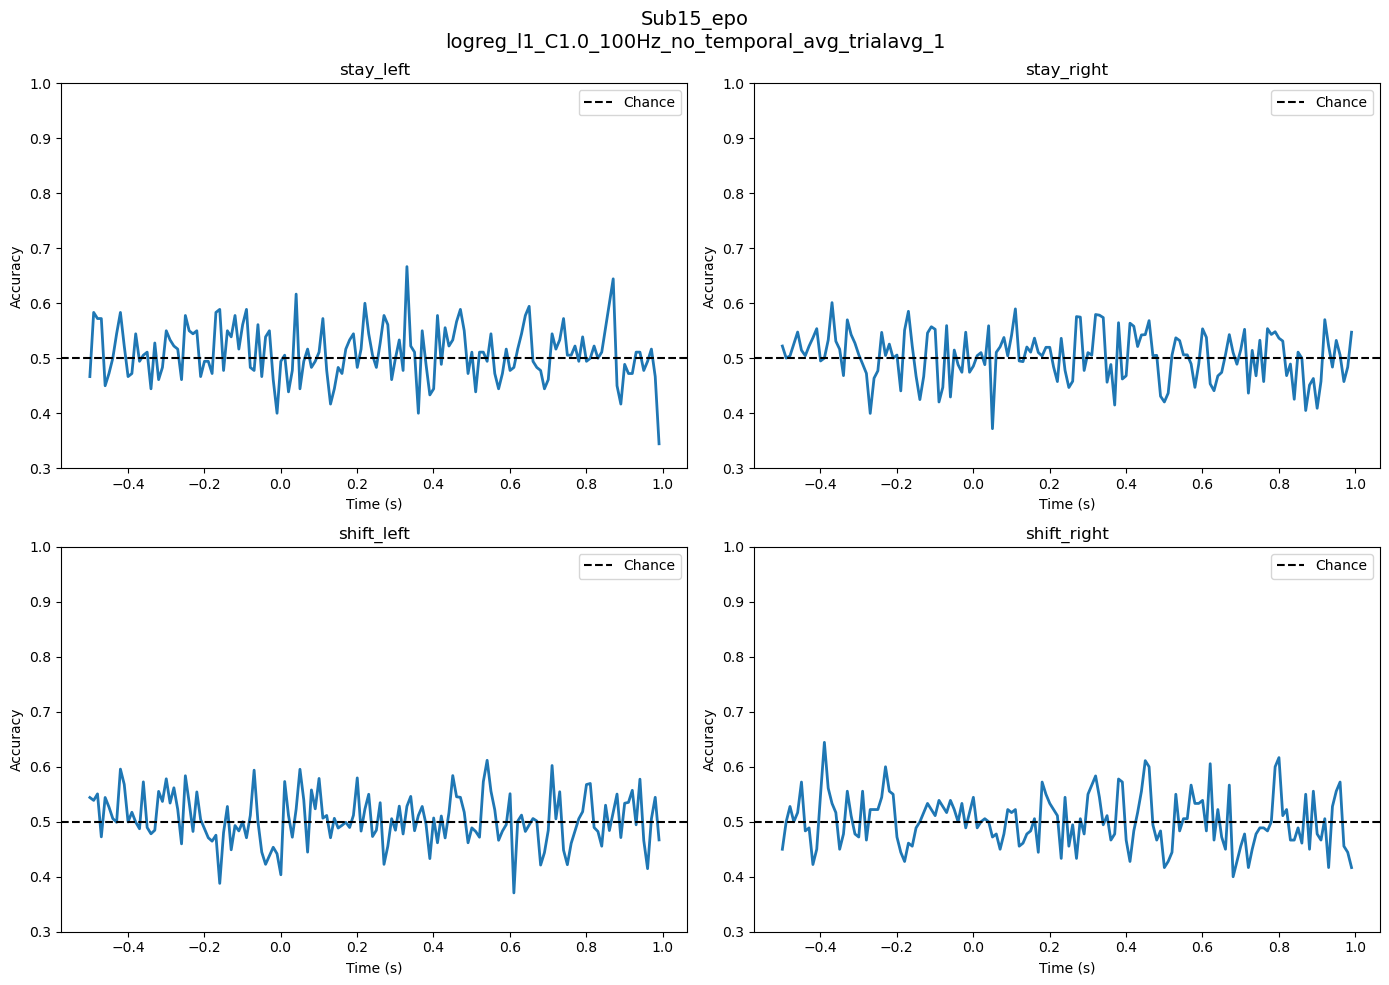

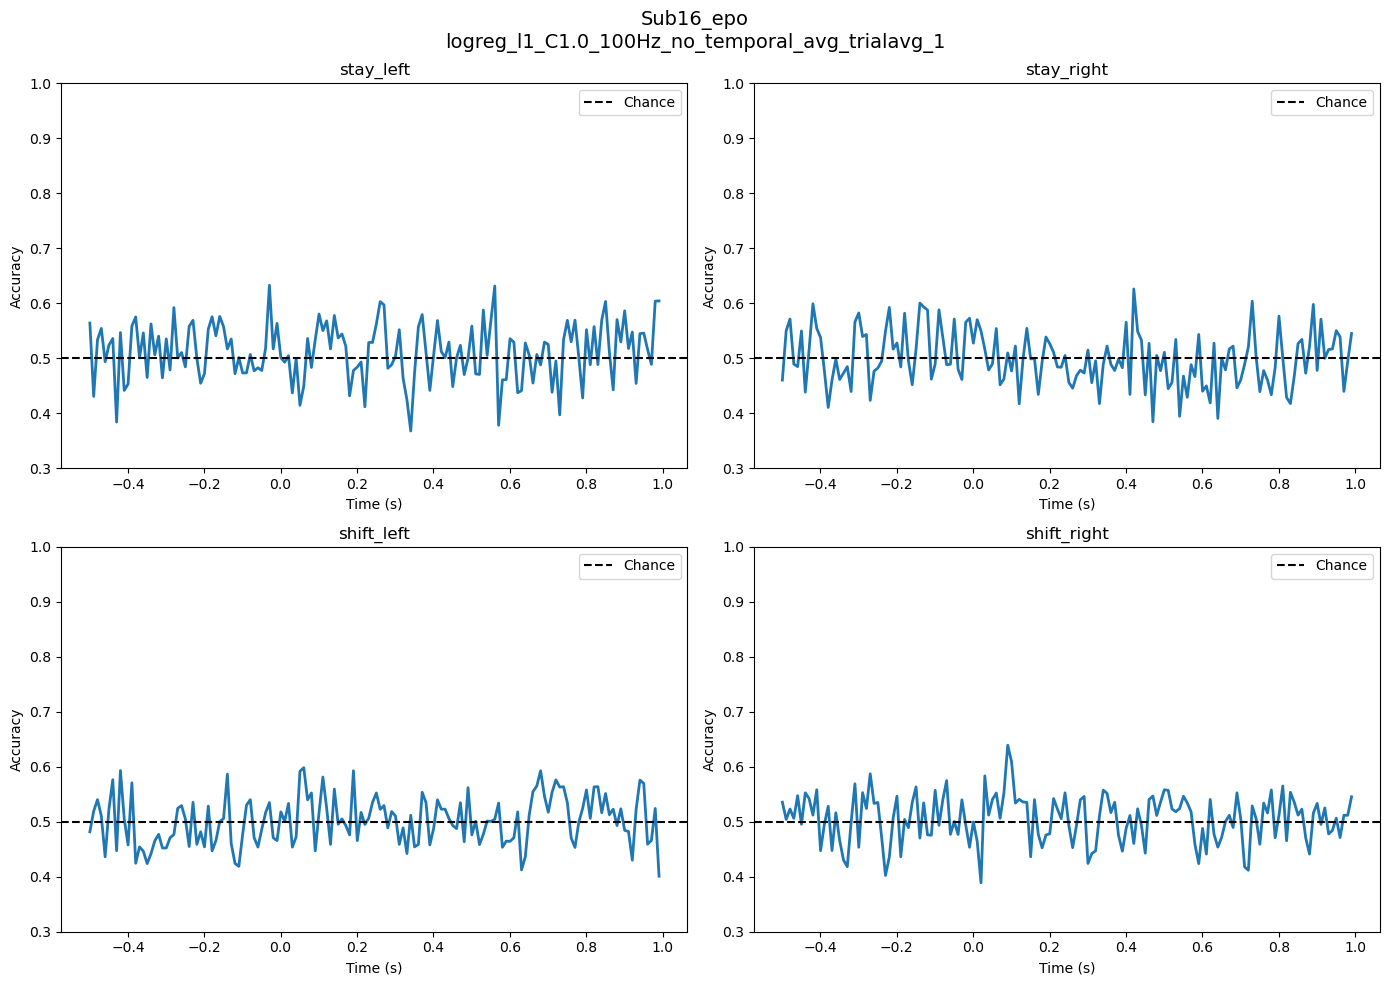

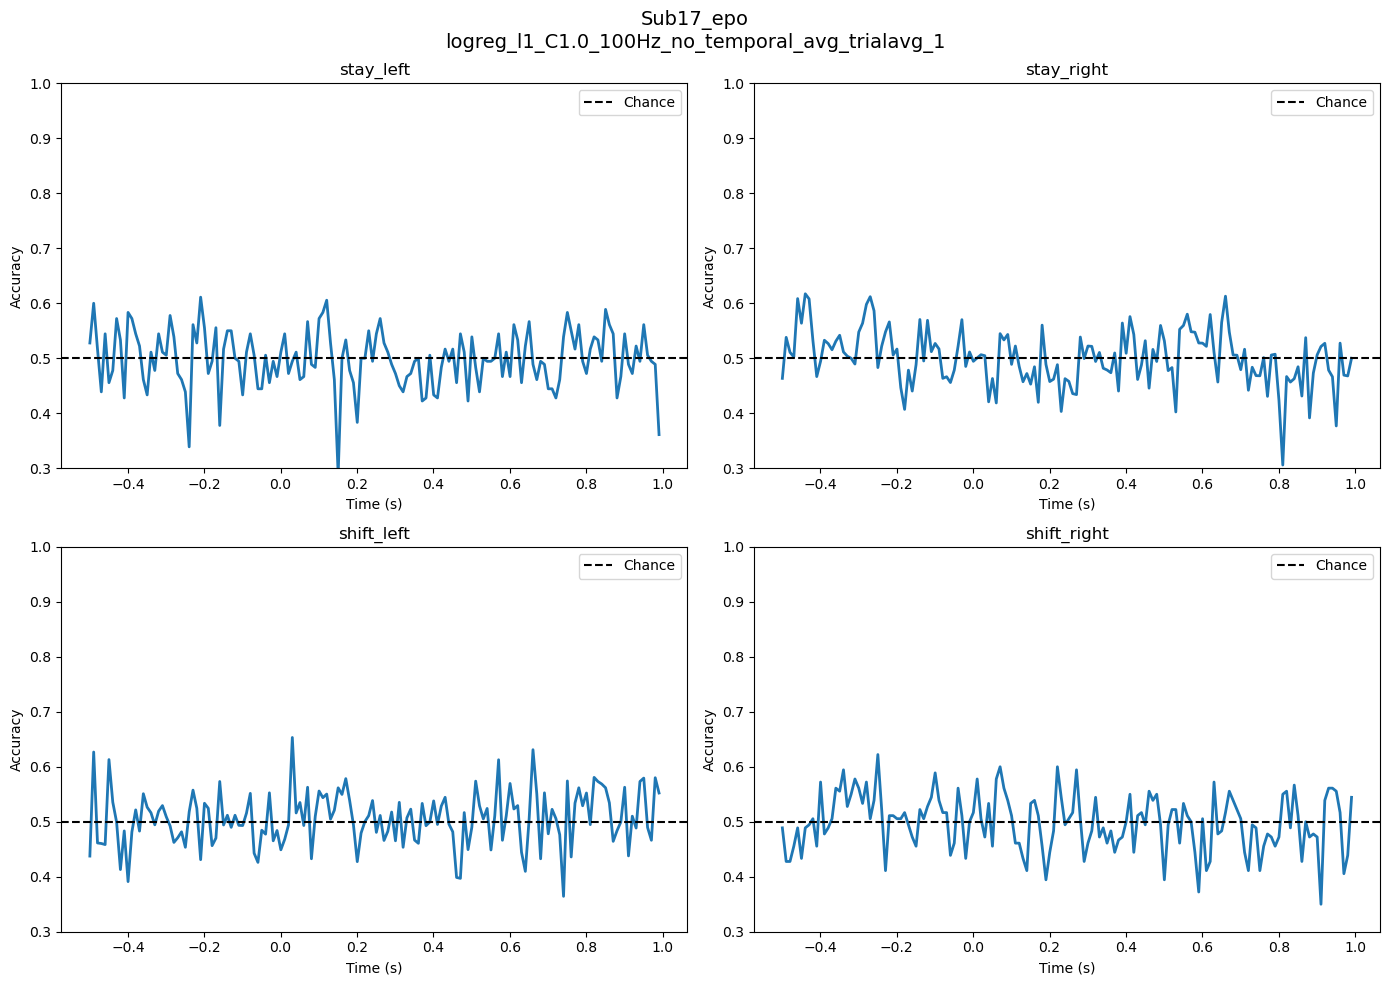

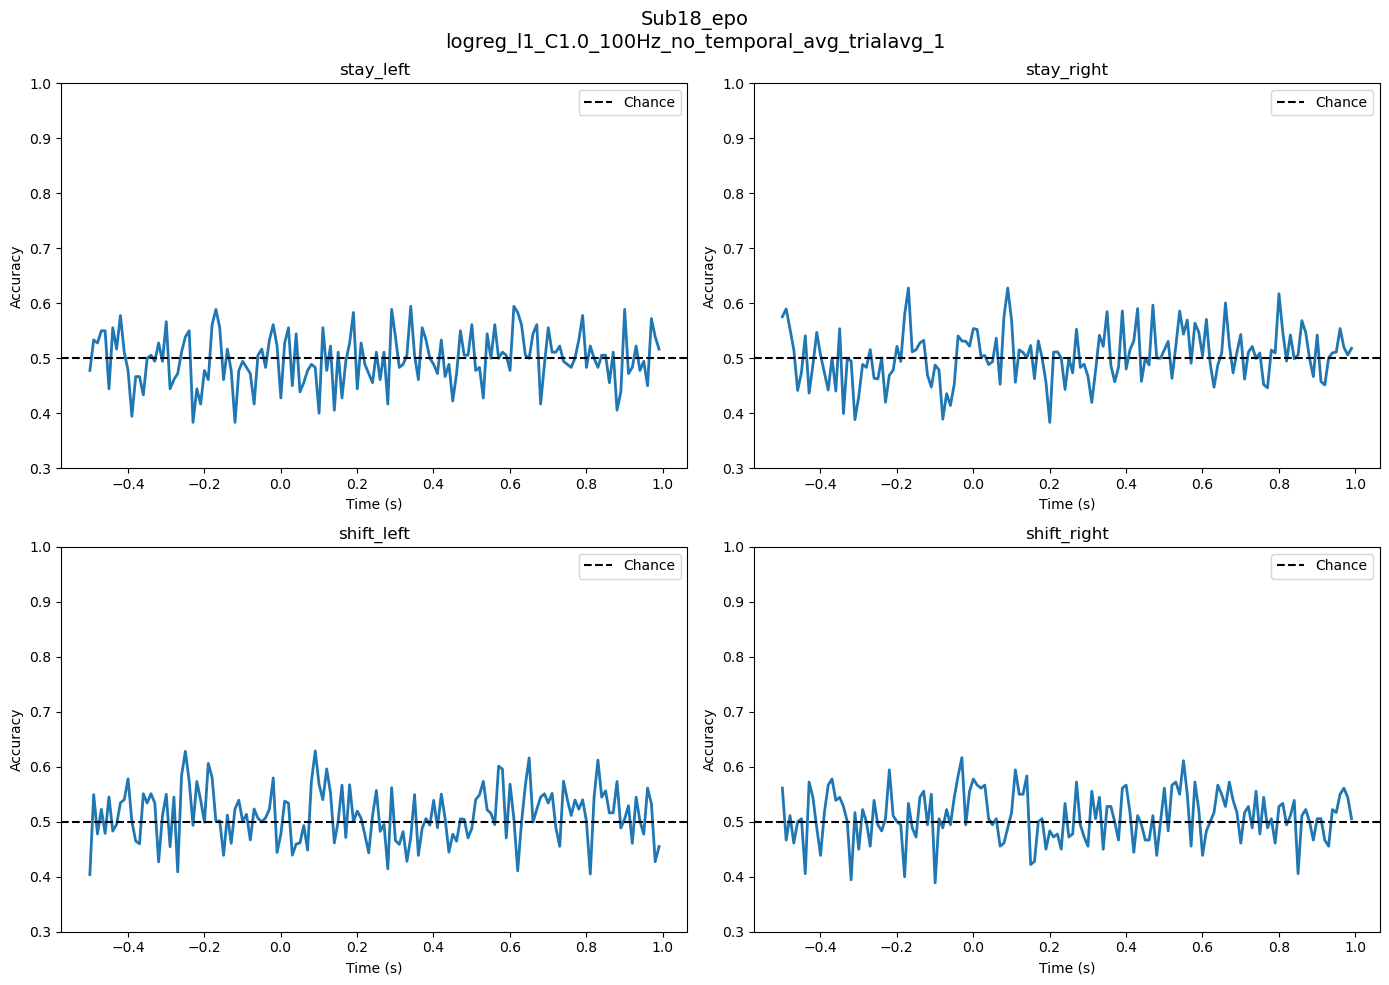

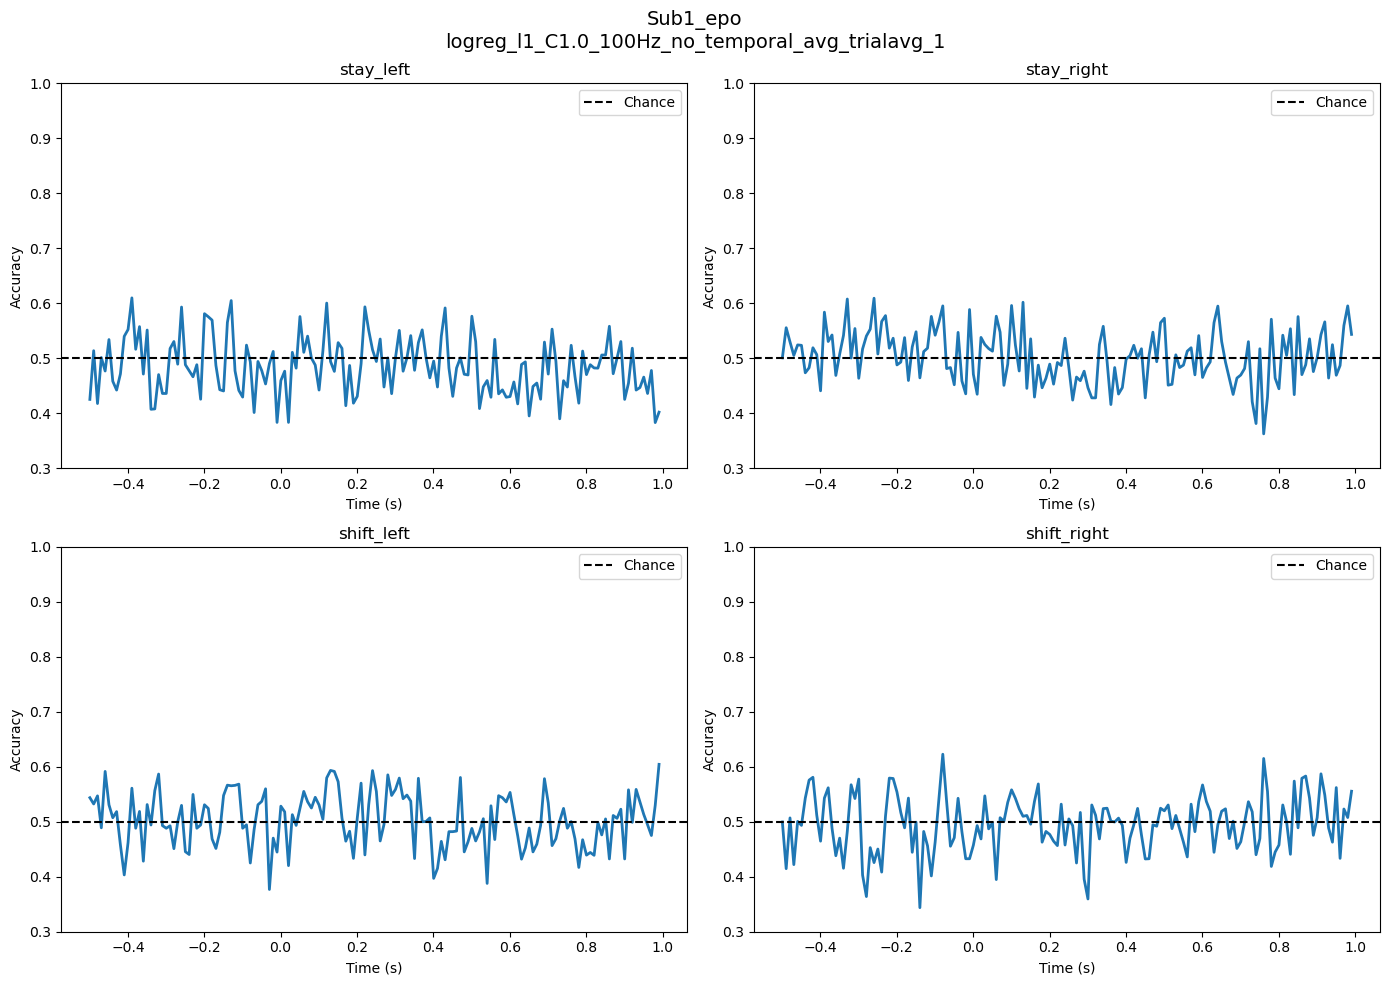

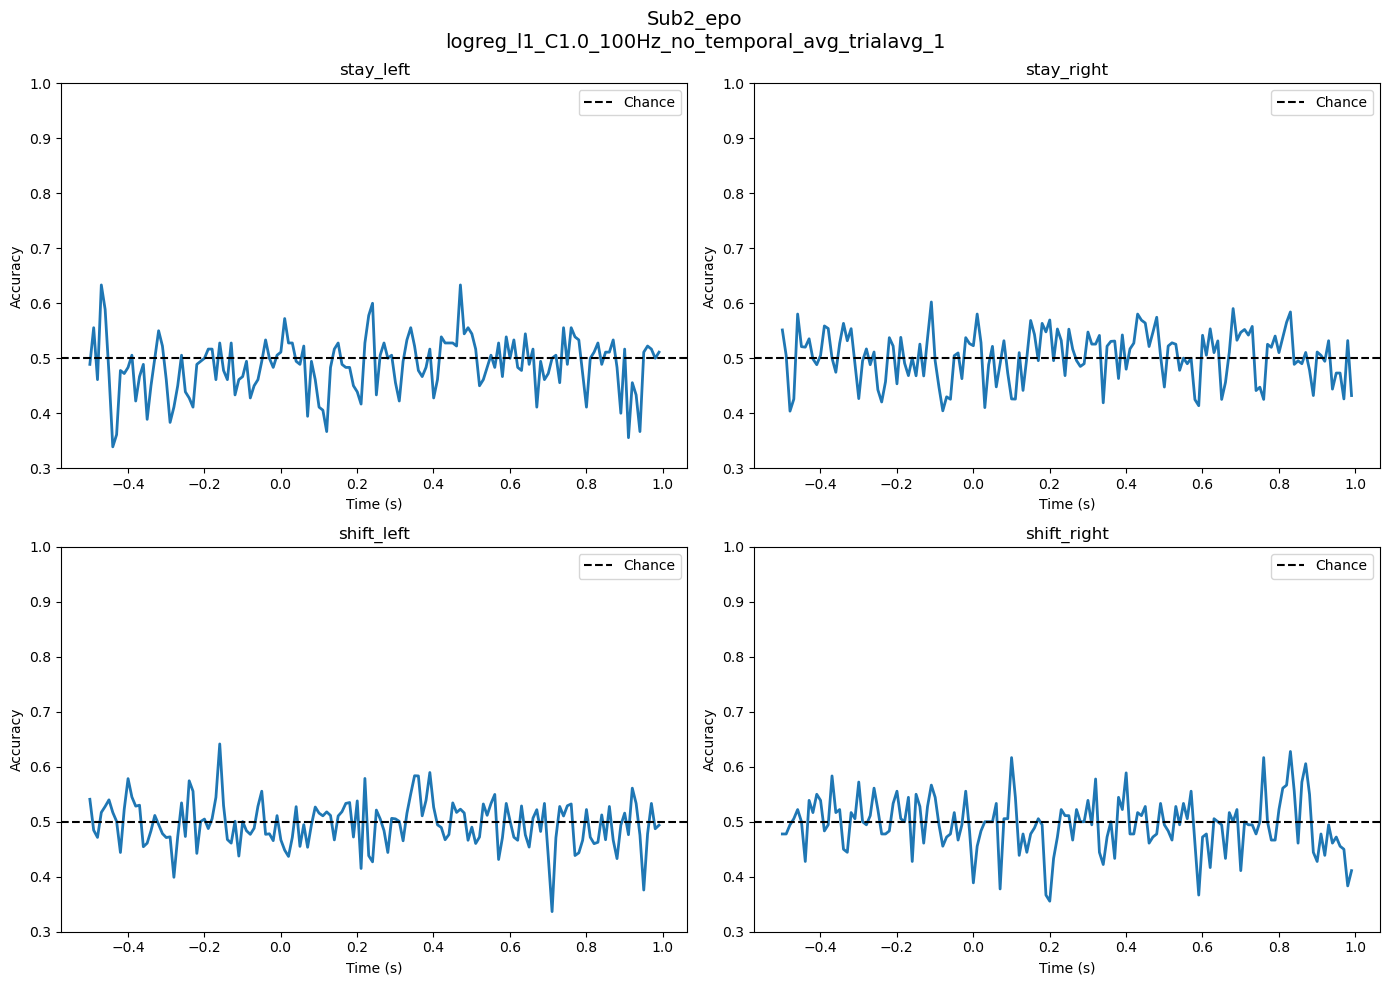

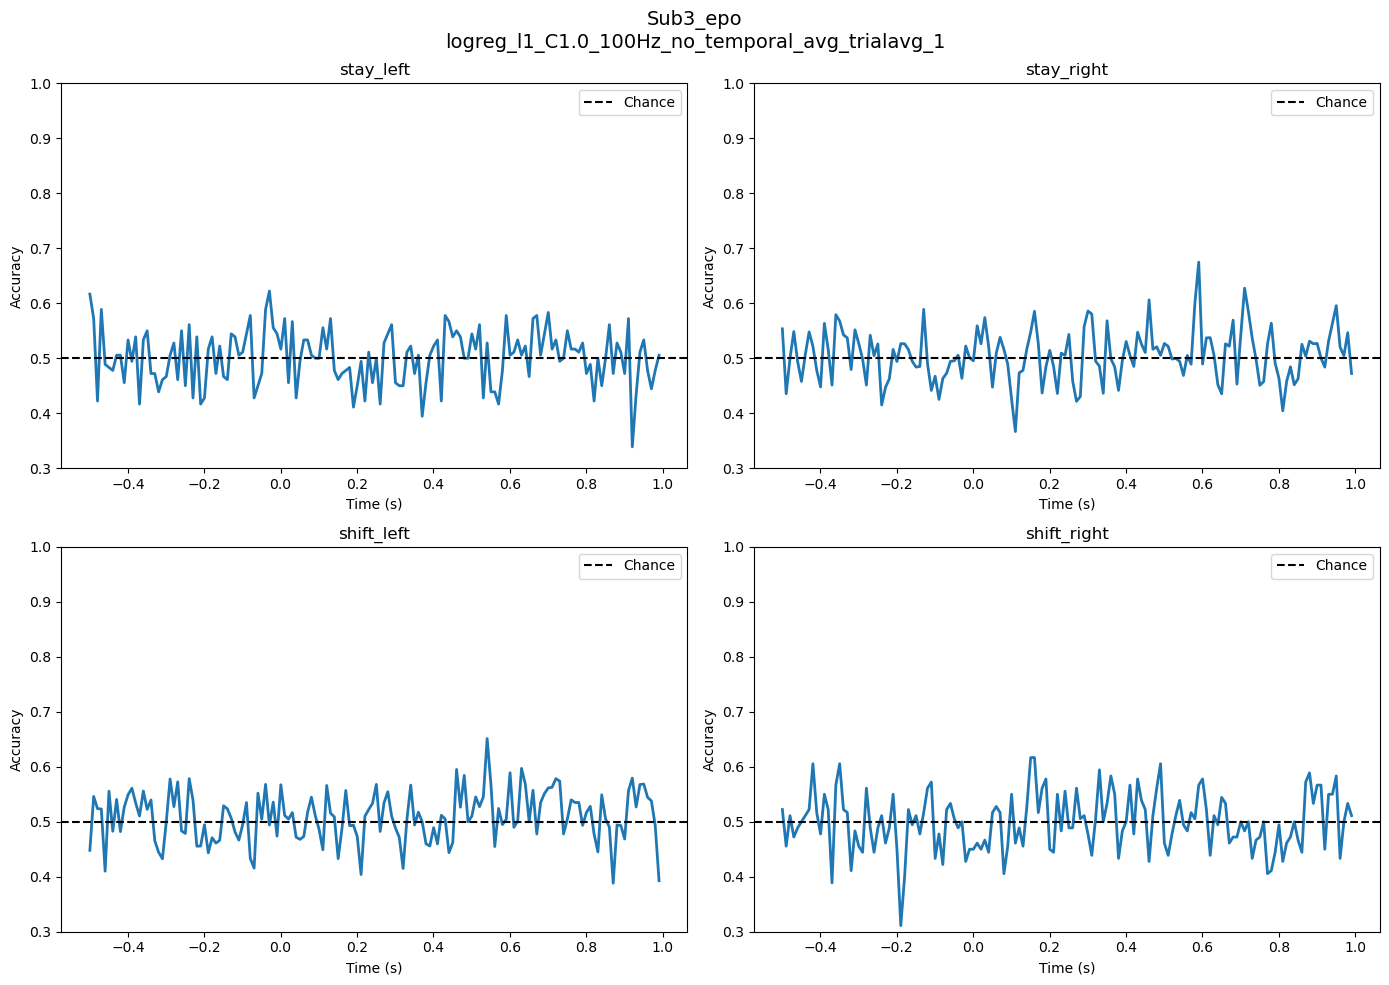

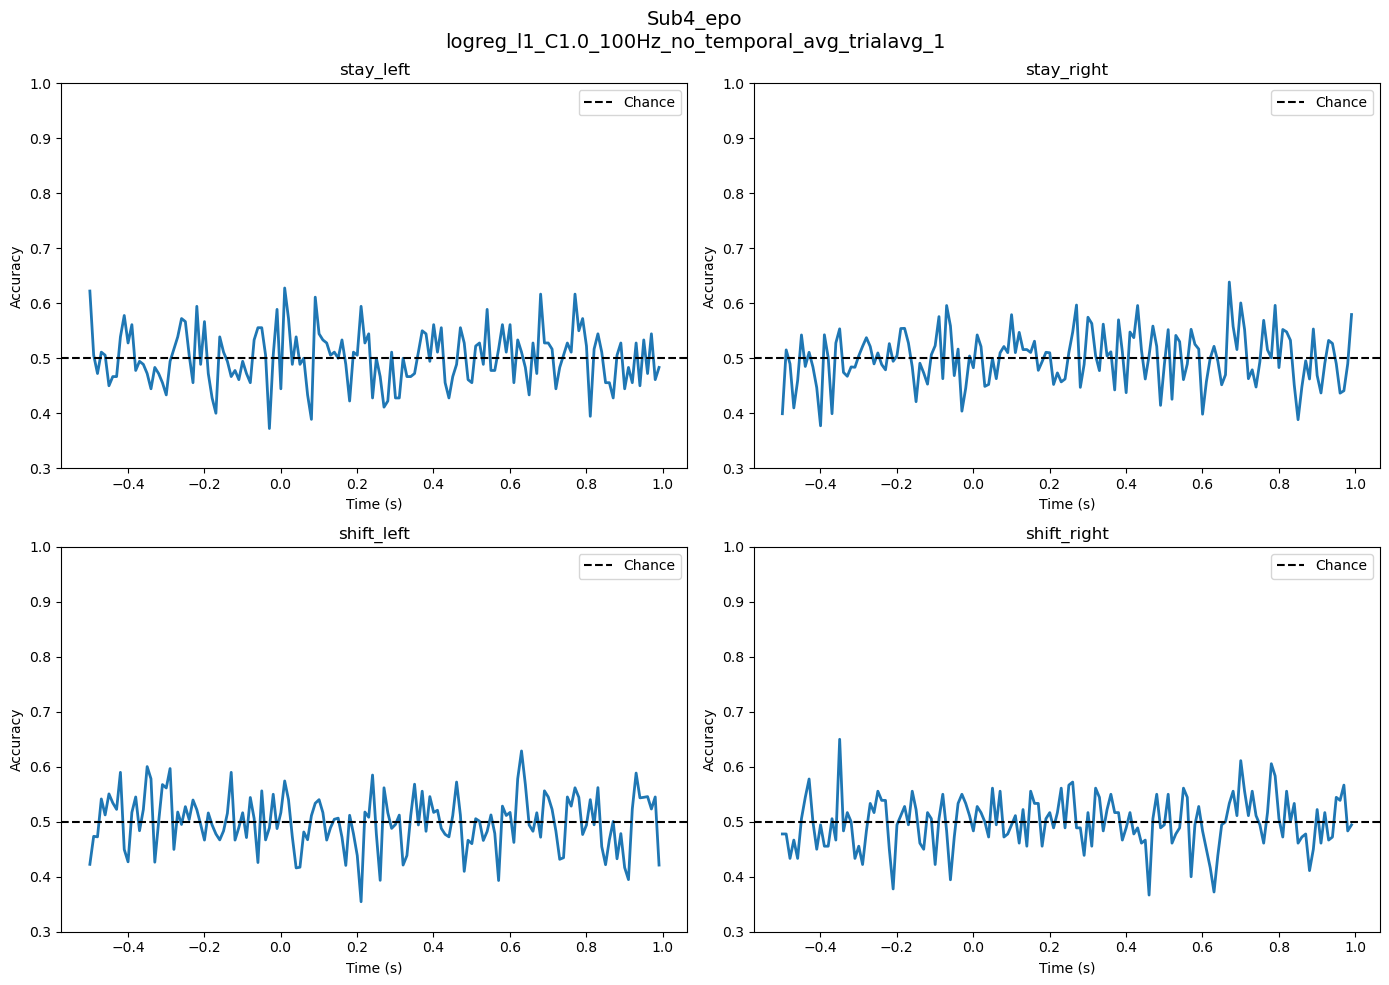

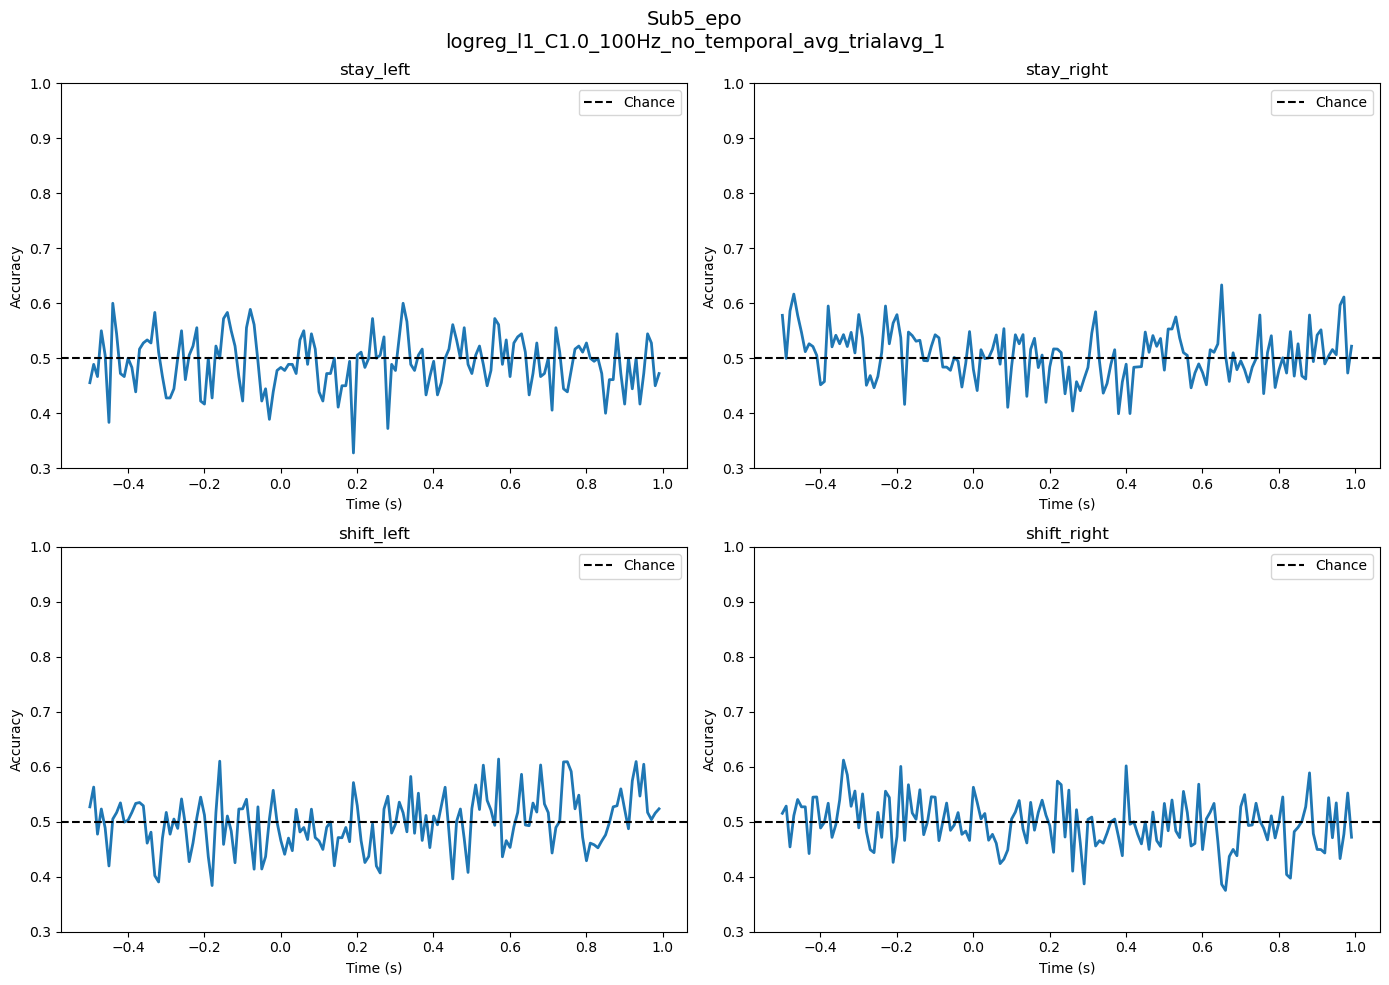

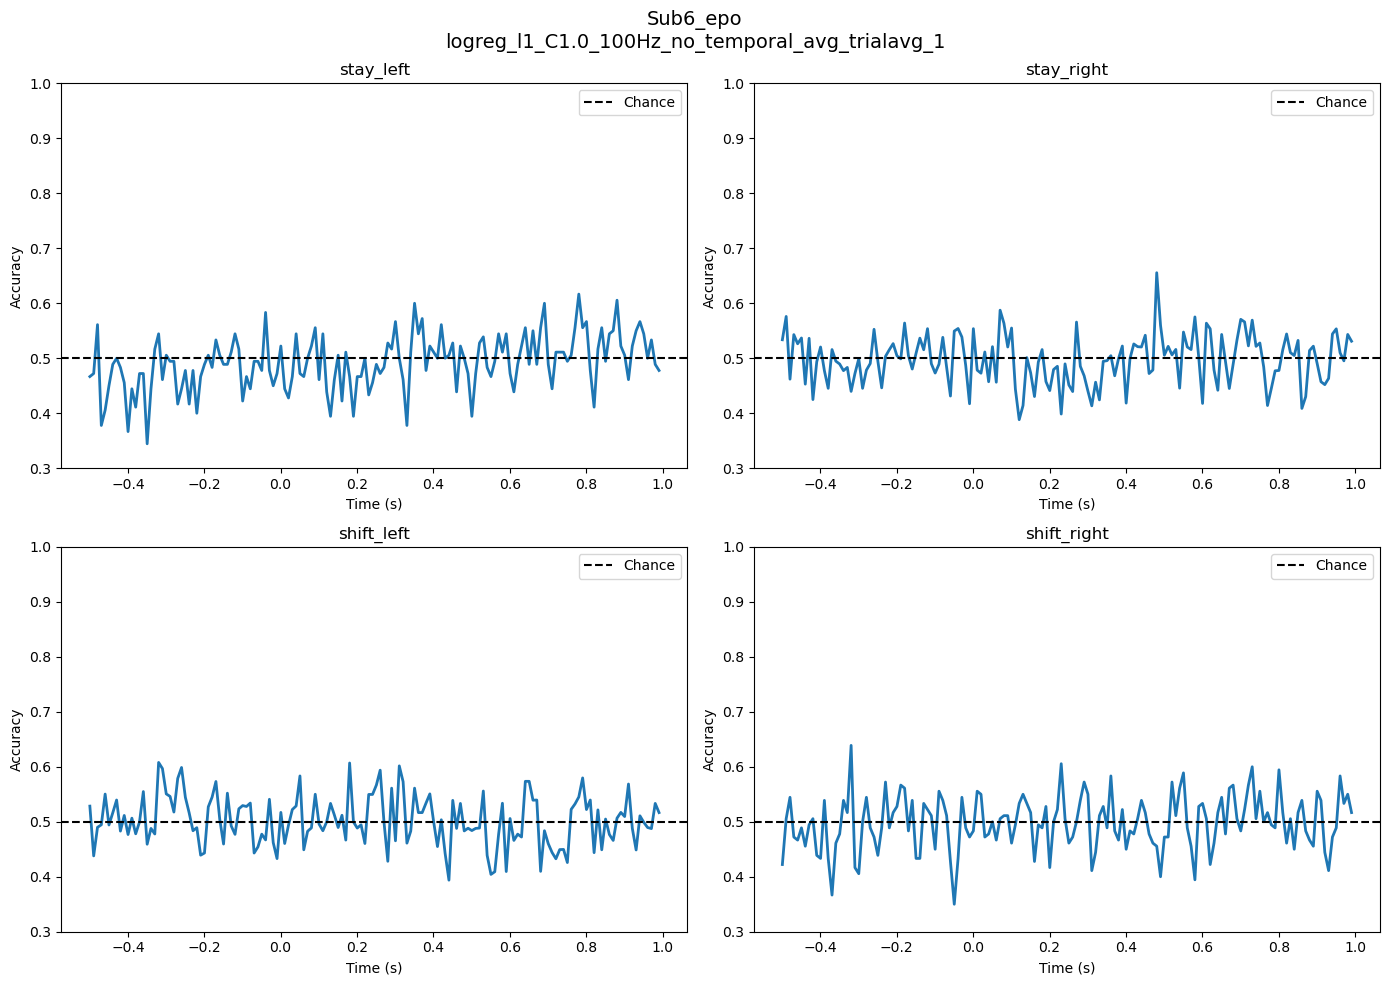

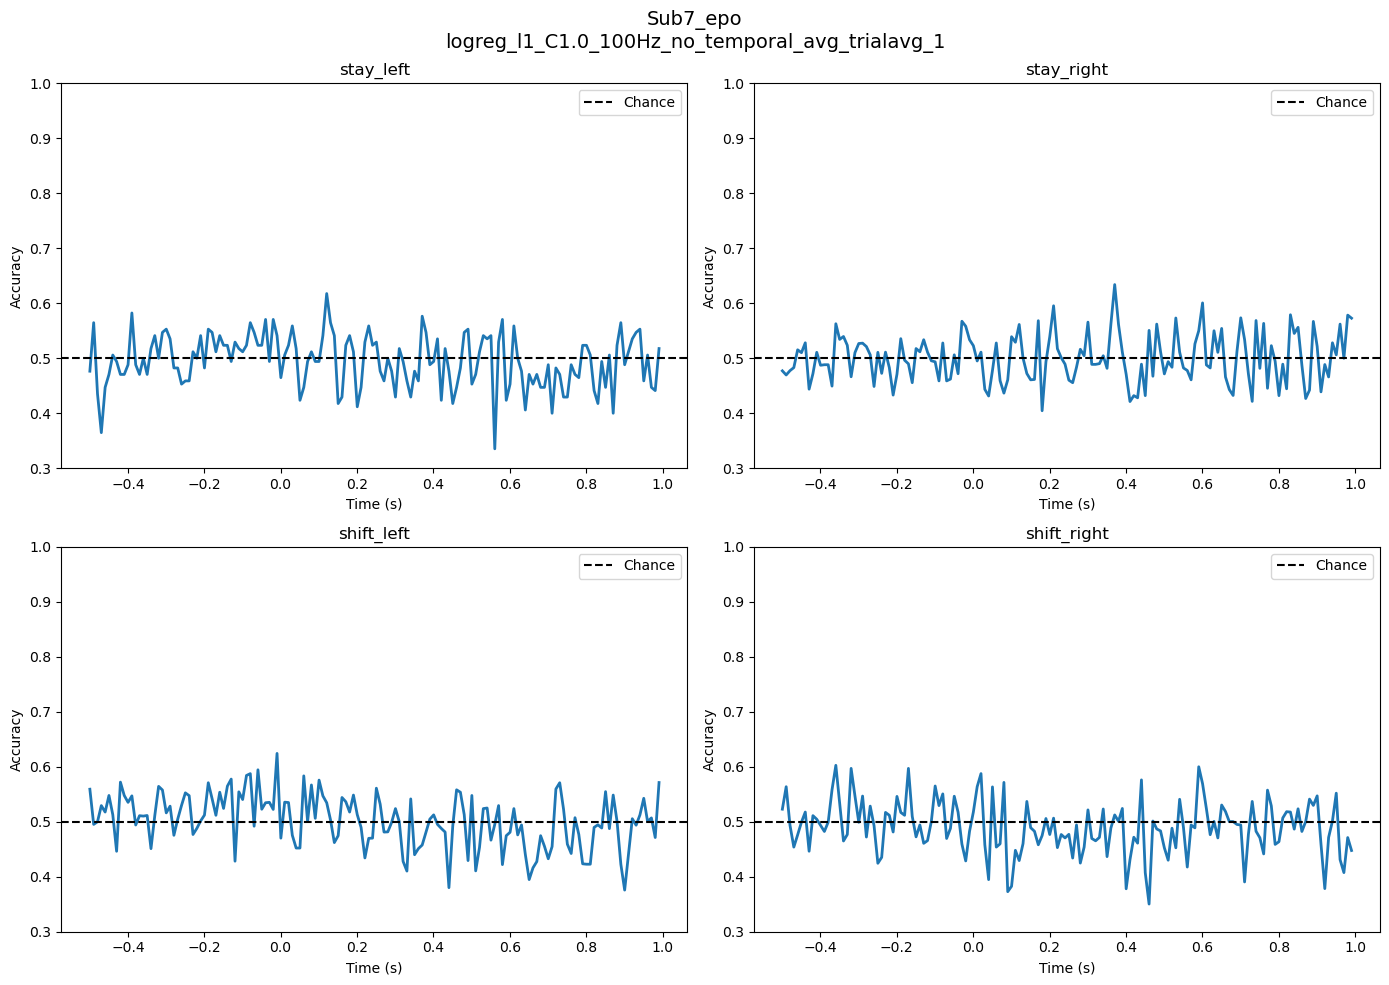

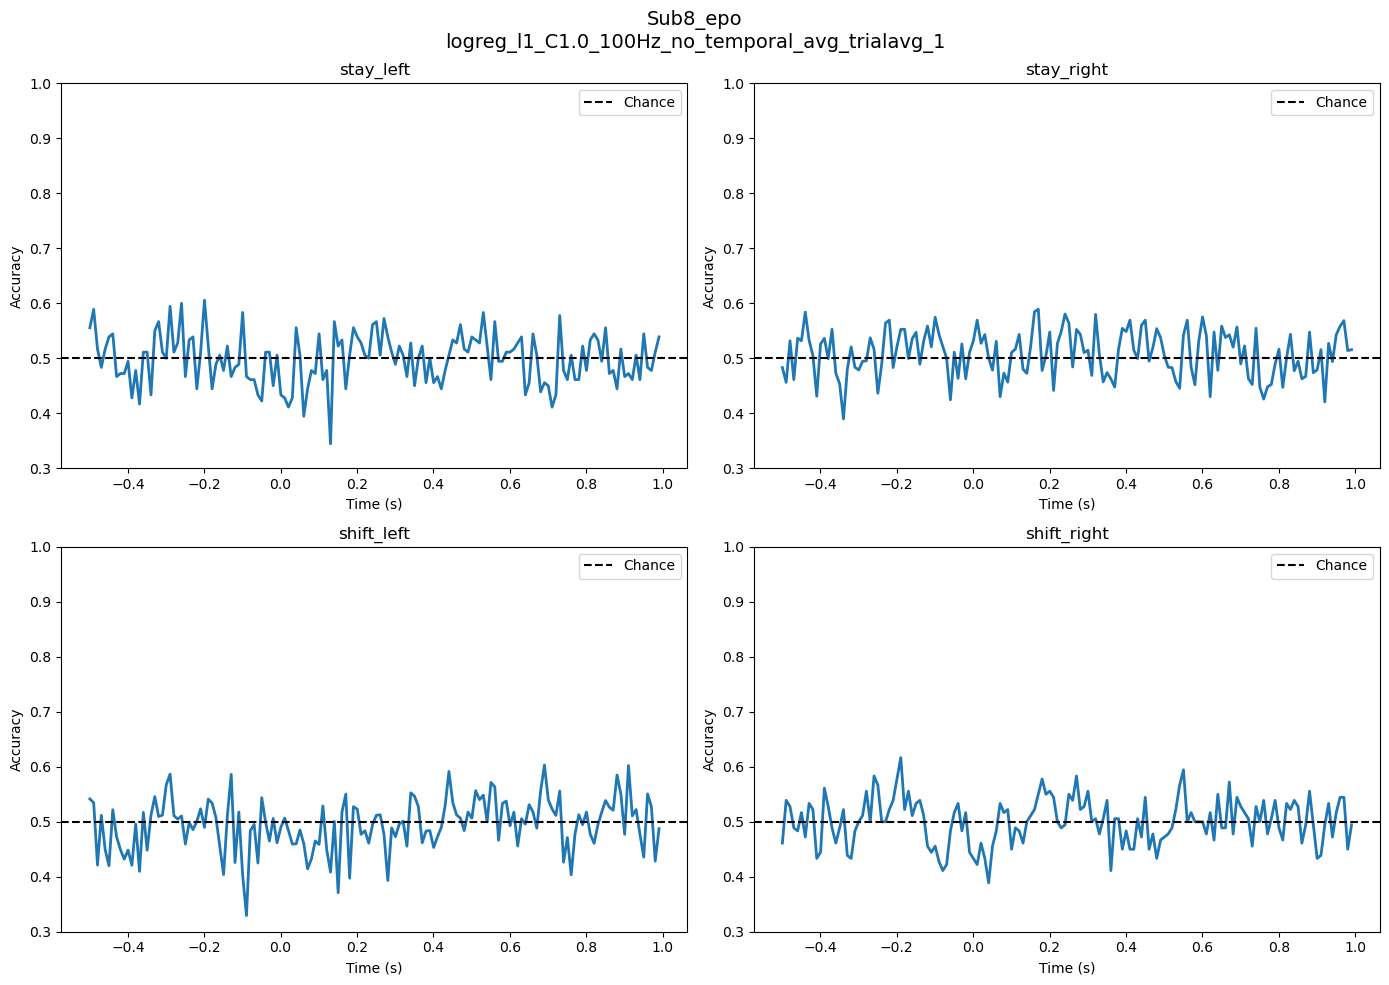

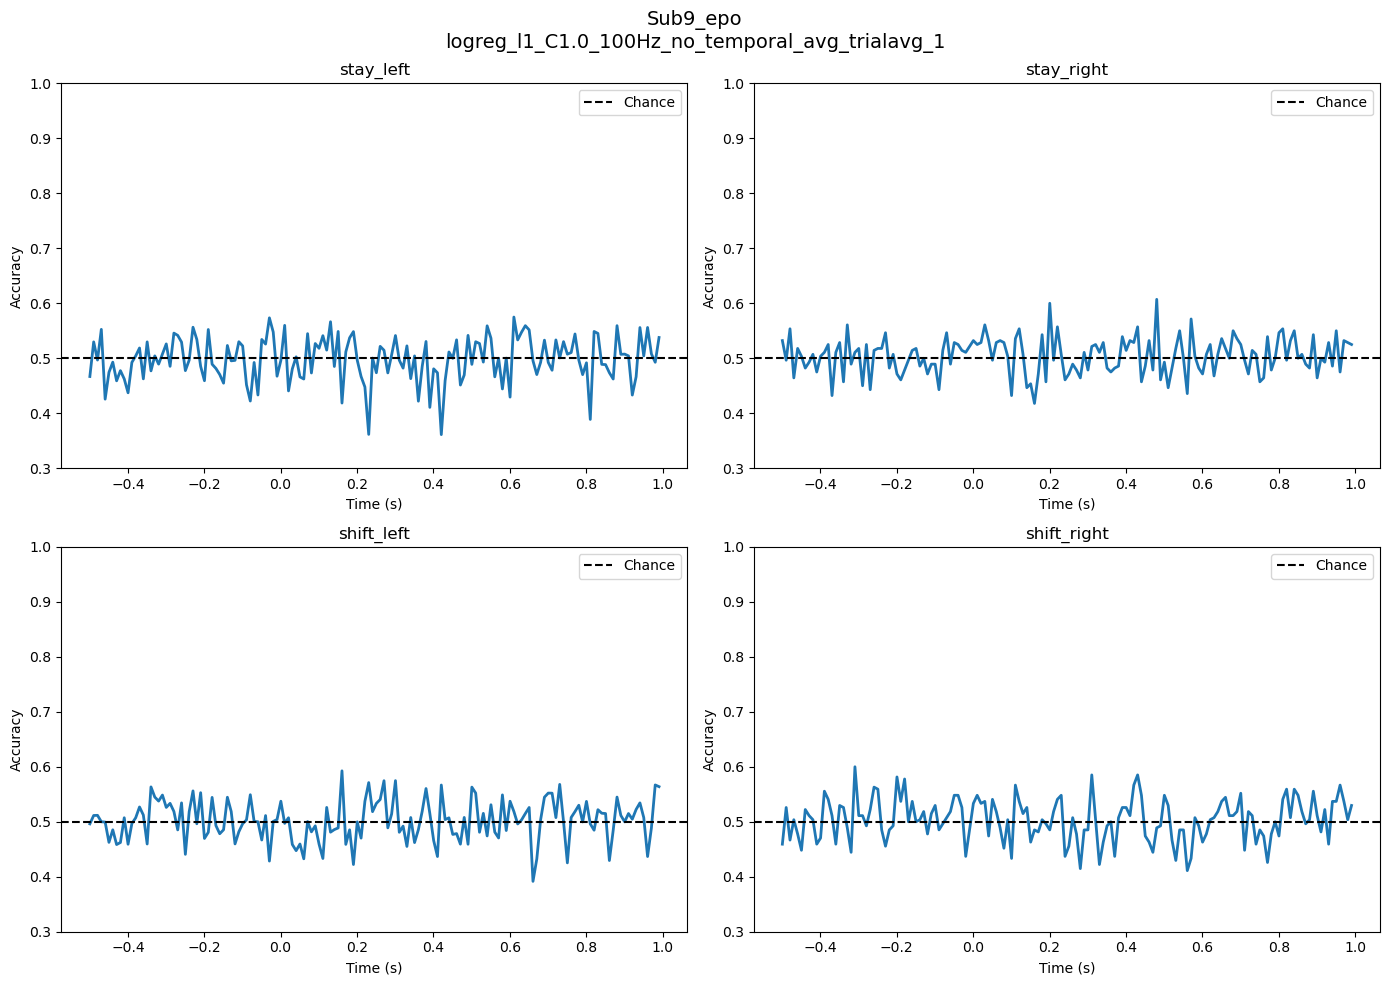

RUNNING THIS FILE:


NameError: name '__file__' is not defined

In [ ]:
# =========================================================
# LOAD COORDINATES
# =========================================================

coordinates = pd.read_excel(
    Path("/path/to/your/directory/config_net_labels_after_VIVI_DEF_MAU_last.xlsx")
)


coords = coordinates[
    ["x", "y", "z"]
].values


labels = coordinates[
    "labels"
].values


print(
    "\nCoordinates loaded."
)

print(
    f"Number of coordinates: "
    f"{len(coords)}"
)


# %%
# =========================================================
# GROUP AVERAGE
# =========================================================

group_avg = {
    cond: np.mean(
        all_scores[cond],
        axis=0
    )
    for cond in conditions.keys()
}


# %%
# =========================================================
# DEBUG
# =========================================================

print(
    "\n===== DEBUG ====="
)

print(
    f"Times shape: {times.shape}"
)


for cond in conditions.keys():

    print(
        cond,
        "scores shape:",
        group_avg[cond].shape
    )

    print(
        cond,
        "participants:",
        len(all_scores[cond])
    )


print(
    "=================\n"
)


# %%
# =========================================================
# SAVE GROUP RESULTS
# =========================================================

#group_average_file = (
 #   output_path /
#    f"{analysis_name}_group_average.npz"
#)


#np.savez_compressed(
#    group_average_file,
#
#    times=times,

#    sampling_frequency=np.array(
#        RESAMPLE_FREQ
#    ),

#    temporal_window_ms=np.array(
#        -1
#        if TEMPORAL_WINDOW_MS is None
#        else TEMPORAL_WINDOW_MS
#    ),

#    window_step_ms=np.array(
#        -1
#        if WINDOW_STEP_MS is None
#        else WINDOW_STEP_MS
#    ),

#    trial_averaging=np.array(
#        TRIAL_AVERAGING
#    ),

#    regularization=np.array(
#        REGULARIZATION
#    ),

#    regularization_strength=np.array(
#        REGULARIZATION_STRENGTH
#    ),

#    **group_avg
#)


#print(
#    f"\nSaved group results:"
#)

#print(
#    group_average_file
#)


# %%
# =========================================================
# SAVE INDIVIDUAL RESULTS
# =========================================================

#individual_file = (
#    output_path /
#    f"{analysis_name}_individual_results.npz"
#)


#np.savez_compressed(
#    individual_file,

#   times=times,

#    **{
#        cond: np.asarray(
#            all_scores[cond]
#        )
#        for cond in conditions.keys()
#    }
#)


#print(
#    f"\nSaved individual results:"
#)

#print(
#    individual_file
#)


# %%
# =========================================================
# PLOT GROUP CLASSIFICATION
# =========================================================

plt.figure(
    figsize=(10, 5)
)


for cond, scores in group_avg.items():

    plt.plot(
        times,
        scores,
        label=cond
    )


plt.axhline(
    0.5,
    color="k",
    linestyle="--",
    label="Chance"
)


plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Accuracy"
)


if TEMPORAL_WINDOW_MS is None:

    title = (
        "Group decoding\n"
        "No temporal averaging"
    )

else:

    title = (
        "Group decoding\n"
        f"{TEMPORAL_WINDOW_MS}-ms window, "
        f"{WINDOW_STEP_MS}-ms step"
    )


plt.title(
    title
)


plt.legend()

plt.tight_layout()


group_plot_file = (
    output_path /
    f"{analysis_name}_group_average.png"
)


plt.savefig(
    group_plot_file,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    f"Saved plot: "
    f"{group_plot_file}"
)


# %%
# =========================================================
# PLOT ONE FIGURE PER CONDITION
# INDIVIDUAL PARTICIPANTS + GROUP MEAN
# =========================================================

for cond in conditions.keys():

    plt.figure(
        figsize=(10, 4)
    )


    # -----------------------------------------------------
    # INDIVIDUAL PARTICIPANTS
    # -----------------------------------------------------

    for subj_scores in all_scores[cond]:

        plt.plot(
            times,
            subj_scores,
            alpha=0.35
        )


    # -----------------------------------------------------
    # GROUP MEAN
    # -----------------------------------------------------

    plt.plot(
        times,
        group_avg[cond],
        color="k",
        lw=2,
        label="Mean"
    )


    # -----------------------------------------------------
    # CHANCE
    # -----------------------------------------------------

    plt.axhline(
        0.5,
        color="k",
        linestyle="--",
        label="Chance"
    )


    plt.xlabel(
        "Time (s)"
    )

    plt.ylabel(
        "Accuracy"
    )


    plt.title(
        f"{cond}\n"
        f"{temporal_name}, "
        f"trial average={TRIAL_AVERAGING}"
    )


    plt.legend()

    plt.tight_layout()


    condition_file = (
        output_path /
        f"{analysis_name}_{cond}.png"
    )


    plt.savefig(
        condition_file,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


# %%
# =========================================================
# PLOT ONE FIGURE PER PARTICIPANT
# FOUR CONDITIONS
# =========================================================

for subj_idx, f in enumerate(files):

    participant_name = f.stem


    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 10)
    )


    axes = axes.ravel()


    for ax, cond_name in zip(
        axes,
        conditions.keys()
    ):

        scores = all_scores[
            cond_name
        ][subj_idx]


        ax.plot(
            times,
            scores,
            lw=2
        )


        ax.axhline(
            0.5,
            color="k",
            linestyle="--",
            label="Chance"
        )


        ax.set_title(
            cond_name
        )


        ax.set_xlabel(
            "Time (s)"
        )

        ax.set_ylabel(
            "Accuracy"
        )


        ax.set_ylim(
            0.3,
            1.0
        )


        ax.legend()


    fig.suptitle(
        f"{participant_name}\n"
        f"{analysis_name}",
        fontsize=14
    )


    plt.tight_layout()


    participant_file = (
        output_path /
        f"{analysis_name}_{participant_name}.png"
    )


    plt.savefig(
        participant_file,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

# %%
# =========================================================
# ONE FIGURE PER CONDITION
# ALL PARTICIPANTS
# =========================================================

n_subjects = len(
    files
)


n_cols = 3


n_rows = int(
    np.ceil(
        n_subjects / n_cols
    )
)


for cond_name in conditions.keys():

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(
            15,
            4 * n_rows
        )
    )


    axes = np.asarray(
        axes
    ).ravel()


    # -----------------------------------------------------
    # PARTICIPANTS
    # -----------------------------------------------------

    for subj_idx, f in enumerate(
        files
    ):

        participant_name = f.stem

        ax = axes[
            subj_idx
        ]


        scores = all_scores[
            cond_name
        ][subj_idx]


        ax.plot(
            times,
            scores,
            lw=2
        )


        ax.axhline(
            0.5,
            color="k",
            linestyle="--"
        )


        ax.set_title(
            participant_name
        )


        ax.set_xlabel(
            "Time (s)"
        )


        ax.set_ylabel(
            "Accuracy"
        )


        ax.set_ylim(
            0.3,
            1.0
        )


    # -----------------------------------------------------
    # HIDE UNUSED AXES
    # -----------------------------------------------------

    for ax in axes[
        n_subjects:
    ]:

        ax.axis(
            "off"
        )


    # -----------------------------------------------------
    # TITLE
    # -----------------------------------------------------

    fig.suptitle(
        f"{cond_name}\n"
        f"{analysis_name}",
        fontsize=16
    )


    plt.tight_layout()


    participant_condition_file = (
        output_path /
        f"{analysis_name}_{cond_name}_"
        f"all_participants.png"
    )


    plt.savefig(
        participant_condition_file,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


# %%
# =========================================================
# CALCULATE GROUP-AVERAGED CLASSIFIER WEIGHTS
# =========================================================

time_mask = (
    (times >= WEIGHT_START_SEC)
    &
    (times <= WEIGHT_END_SEC)
)


group_weights = {}


if not np.any(
    time_mask
):

    print(
        "\nWARNING:"
    )

    print(
        "No time points/windows found "
        "inside weight interval."
    )


else:

    # =====================================================
    # LOOP CONDITIONS
    # =====================================================

    for cond in conditions.keys():

        subj_weights = []


        # -------------------------------------------------
        # PARTICIPANTS
        # -------------------------------------------------

        for subj_idx in range(
            len(files)
        ):

            w = all_weights[
                cond
            ][subj_idx]


            # -------------------------------------------------
            # AVERAGE ACROSS SELECTED TIME INTERVAL
            # -------------------------------------------------

            w_avg_time = np.mean(
                w[
                    time_mask
                ],
                axis=0
            )


            subj_weights.append(
                w_avg_time
            )


        # -------------------------------------------------
        # GROUP AVERAGE
        # -------------------------------------------------

        group_weights[
            cond
        ] = np.mean(
            subj_weights,
            axis=0
        )


# %%
# =========================================================
# SAVE CLASSIFIER WEIGHTS
# =========================================================

if len(
    group_weights
) > 0:

    weights_file = (
        output_path /
        f"{analysis_name}_weights.npz"
    )


    np.savez_compressed(
        weights_file,

        weight_start_sec=np.array(
            WEIGHT_START_SEC
        ),

        weight_end_sec=np.array(
            WEIGHT_END_SEC
        ),

        **group_weights
    )


    print(
        f"\nSaved classifier weights:"
    )

    print(
        weights_file
    )


# %%
# =========================================================
# PLOT CLASSIFIER WEIGHTS
# GLASS BRAIN
# =========================================================

if len(
    group_weights
) > 0:

    # -----------------------------------------------------
    # COLOR SCALE
    # -----------------------------------------------------

    all_weight_values = np.concatenate(
        [
            np.abs(
                group_weights[cond]
            )
            for cond in conditions.keys()
        ]
    )


    vmax = np.percentile(
        all_weight_values,
        95
    )


    if vmax == 0:

        vmax = 1.0


    vmin = -vmax


    norm = plt.Normalize(
        vmin=vmin,
        vmax=vmax
    )


    cmap = plt.cm.seismic


    # =====================================================
    # LOOP CONDITIONS
    # =====================================================

    for cond in conditions.keys():

        weights = group_weights[
            cond
        ]


        colors = cmap(
            norm(weights)
        )


        display = plotting.plot_glass_brain(
            None,

            display_mode="lyrz",

            colorbar=False,

            threshold=None,

            title=(
                f"{cond}\n"
                f"Weights averaged "
                f"{WEIGHT_START_SEC}-"
                f"{WEIGHT_END_SEC}s"
            )
        )


        # -------------------------------------------------
        # ADD MARKERS
        # -------------------------------------------------

        for coord, color in zip(
            coords,
            colors
        ):

            display.add_markers(
                [coord],

                marker_color=[
                    color
                ],

                marker_size=50
            )


        weight_plot_file = (
            output_path /
            f"{analysis_name}_"
            f"{cond}_weights.png"
        )


        plt.savefig(
            weight_plot_file,
            dpi=300,
            bbox_inches="tight"
        )


        plt.show()


# %%
# =========================================================
# FINAL MESSAGE
# =========================================================

print(
    "\n=============================================="
)

print(
    "ANALYSIS COMPLETE"
)

print(
    "=============================================="
)

print(
    f"Sampling frequency: "
    f"{RESAMPLE_FREQ} Hz"
)

print(
    f"Temporal window: "
    f"{TEMPORAL_WINDOW_MS}"
)

print(
    f"Window step: "
    f"{WINDOW_STEP_MS}"
)

print(
    f"Training trial averaging: "
    f"{TRIAL_AVERAGING}"
)

print(
    f"Regularization: "
    f"{REGULARIZATION}"
)

print(
    f"C: "
    f"{REGULARIZATION_STRENGTH}"
)

print(
    f"\nResults prefix:"
)

print(
    analysis_name
)

print(
    "=============================================="
)

